# Modelo de Clasificación - Detección de Anomalías en Consumo Eléctrico
<br>

**Objetivo:** Desarrollar un modelo de clasificación para detectar anomalías en el consumo eléctrico utilizando **SVM, XGBoost, KNN y Random Forest** con optimización de hiperparámetros.

**Variable Objetivo:** `Abnormal_Usage` (0 = Normal, 1 = Anómalo)

**Algoritmos a utilizar:**
- Support Vector Machine (SVM)
- XGBoost (Extreme Gradient Boosting)
- K-Nearest Neighbors (KNN)
- Random Forest

## 1. Importar las librerías necesarias

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve, average_precision_score)

# Modelos
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Para manejo de desbalance (si es necesario)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import pickle

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Cargar los datos limpios

In [2]:
# Cargar el dataset limpio
df = pd.read_csv('../data/dataset_limpio.csv')

print("Datos cargados:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas:")
print(df.columns.tolist())
print(f"\nPrimeras 5 filas:")
df.head()

Datos cargados:
Dimensiones: (10800, 19)

Columnas:
['Num_Occupants', 'House_Area (sqft)', 'Appliance_Score', 'Connected_Load(kw)', 'Temperature_C', 'Humidity (%)', 'Expected_Energy(kwh)', 'Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Cluster_Avg_Energy(kwh)', 'Abnormal_Usage', 'Month', 'Year', 'Region_Code_IN_KL_ALP', 'Region_Code_IN_KL_ERN', 'Region_Code_IN_KL_TVM', 'Dwelling_Type_Apartment', 'Dwelling_Type_Independent House', 'Dwelling_Type_Villa']

Primeras 5 filas:


,Num_Occupants,House_Area (sqft),Appliance_Score,Connected_Load(kw),Temperature_C,Humidity (%),Expected_Energy(kwh),Actual_Energy(kwh),Usage_Deviation(%),Cluster_Avg_Energy(kwh),Abnormal_Usage,Month,Year,Region_Code_IN_KL_ALP,Region_Code_IN_KL_ERN,Region_Code_IN_KL_TVM,Dwelling_Type_Apartment,Dwelling_Type_Independent House,Dwelling_Type_Villa
0,2,1.108194,6,1.225870,-0.108795,1.633974,-1.036012,0.319133,1.460891,0.228746,1,1,2023,0,0,1,0,1,0
1,3,0.878010,9,1.723842,-1.033049,-1.389365,-0.395372,-0.516777,-0.371645,2.110315,0,1,2023,1,0,0,0,1,0
2,3,1.060180,16,0.100582,0.489842,-1.574734,0.304458,-0.593185,-0.934931,0.969364,0,1,2023,0,0,1,1,0,0
3,1,1.572799,18,0.061779,-2.205274,-0.545198,-1.074312,0.581787,1.912708,-0.331721,1,1,2023,0,1,0,1,0,0
4,4,1.010754,10,-1.503276,0.239366,1.088311,-0.788809,-1.059273,-0.823463,-0.692021,0,1,2023,0,1,0,0,1,0


## 3. Verificación de los datos preprocesados

In [3]:
# Información del dataset
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Num_Occupants                    10800 non-null  int64  
 1   House_Area (sqft)                10800 non-null  float64
 2   Appliance_Score                  10800 non-null  int64  
 3   Connected_Load(kw)               10800 non-null  float64
 4   Temperature_C                    10800 non-null  float64
 5   Humidity (%)                     10800 non-null  float64
 6   Expected_Energy(kwh)             10800 non-null  float64
 7   Actual_Energy(kwh)               10800 non-null  float64
 8   Usage_Deviation(%)               10800 non-null  float64
 9   Cluster_Avg_Energy(kwh)          10800 non-null  float64
 10  Abnormal_Usage                   10800 non-null  int64  
 11  Month                            10800 non-null  int64  
 12  Year

In [4]:
# Verificar valores faltantes
print("Valores faltantes:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No hay valores faltantes")
else:
    print(missing[missing > 0])

Valores faltantes:
No hay valores faltantes


In [5]:
# Distribución de la variable objetivo
print("Distribución de la variable objetivo (Abnormal_Usage):")
print(df['Abnormal_Usage'].value_counts())
print(f"\nPorcentajes:")
print(df['Abnormal_Usage'].value_counts(normalize=True) * 100)

Distribución de la variable objetivo (Abnormal_Usage):
Abnormal_Usage
0    6061
1    4739
Name: count, dtype: int64

Porcentajes:
Abnormal_Usage
0    56.12037
1    43.87963
Name: proportion, dtype: float64


## 4. Preparación de los datos para modelado

### 4.1 Separar features (X) y variable objetivo (y)

In [6]:
# Separar features y target
X = df.drop('Abnormal_Usage', axis=1)
y = df['Abnormal_Usage']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\nFeatures utilizadas: {X.columns.tolist()}")

Shape de X (features): (10800, 18)
Shape de y (target): (10800,)

Features utilizadas: ['Num_Occupants', 'House_Area (sqft)', 'Appliance_Score', 'Connected_Load(kw)', 'Temperature_C', 'Humidity (%)', 'Expected_Energy(kwh)', 'Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Cluster_Avg_Energy(kwh)', 'Month', 'Year', 'Region_Code_IN_KL_ALP', 'Region_Code_IN_KL_ERN', 'Region_Code_IN_KL_TVM', 'Dwelling_Type_Apartment', 'Dwelling_Type_Independent House', 'Dwelling_Type_Villa']


### 4.2 División en conjuntos de entrenamiento y prueba

In [7]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Mantener la proporción de clases
)

print("División de datos:")
print(f"  - Entrenamiento: {X_train.shape[0]} muestras ({(len(X_train)/len(X))*100:.1f}%)")
print(f"  - Prueba: {X_test.shape[0]} muestras ({(len(X_test)/len(X))*100:.1f}%)")

print(f"\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())
print(f"\nDistribución de clases en prueba:")
print(y_test.value_counts())

División de datos:
  - Entrenamiento: 8640 muestras (80.0%)
  - Prueba: 2160 muestras (20.0%)

Distribución de clases en entrenamiento:
Abnormal_Usage
0    4849
1    3791
Name: count, dtype: int64

Distribución de clases en prueba:
Abnormal_Usage
0    1212
1     948
Name: count, dtype: int64


### 4.3 Escalado de features

In [8]:
# Inicializar el escalador
scaler = StandardScaler()

# Ajustar con train y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"\nEstadísticas después del escalado (train):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))


Estadísticas después del escalado (train):
      Num_Occupants  House_Area (sqft)  Appliance_Score  Connected_Load(kw)  \
mean            0.0                0.0              0.0                -0.0   
std             1.0                1.0              1.0                 1.0   

      Temperature_C  Humidity (%)  Expected_Energy(kwh)  Actual_Energy(kwh)  \
mean            0.0          -0.0                  -0.0                 0.0   
std             1.0           1.0                   1.0                 1.0   

      Usage_Deviation(%)  Cluster_Avg_Energy(kwh)  Month  Year  \
mean                -0.0                     -0.0    0.0   0.0   
std                  1.0                      1.0    0.0   0.0   

      Region_Code_IN_KL_ALP  Region_Code_IN_KL_ERN  Region_Code_IN_KL_TVM  \
mean                   -0.0                   -0.0                   -0.0   
std                     1.0                    1.0                    1.0   

      Dwelling_Type_Apartment  Dwelling_Type_Inde

## 5. Modelo 1: Support Vector Machine (SVM)

### 5.1 Modelo base (sin optimización)

In [9]:
# Entrenar SVM con parámetros por defecto
print("Entrenando SVM con parámetros por defecto...")
svm_base = SVC(random_state=RANDOM_STATE, probability=True)
svm_base.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svm_base = svm_base.predict(X_test_scaled)
y_pred_proba_svm_base = svm_base.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("RESULTADOS SVM BASE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_base):.4f}") #Precision es la capacidad del modelo para no etiquetar como positivo (anómalo) un caso que es negativo (normal).
print(f"Recall: {recall_score(y_test, y_pred_svm_base):.4f}") #recall es la capacidad del modelo para identificar correctamente los casos positivos (anómalos)
print(f"F1-Score: {f1_score(y_test, y_pred_svm_base):.4f}") #F1-Score es la media armónica entre precision y recall, útil para evaluar modelos en datasets desbalanceados.
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm_base):.4f}") #ROC-AUC sirve para evaluar la capacidad del modelo para distinguir entre clases.

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm_base, target_names=['Normal', 'Anómalo']))

Entrenando SVM con parámetros por defecto...
RESULTADOS SVM BASE
Accuracy: 0.8931
Precision: 0.9786
Recall: 0.7732
F1-Score: 0.8639
ROC-AUC: 0.9420

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91      1212
     Anómalo       0.98      0.77      0.86       948

    accuracy                           0.89      2160
   macro avg       0.91      0.88      0.89      2160
weighted avg       0.91      0.89      0.89      2160



### 5.2 Optimización con Grid Search

Hiperparámetros a optimizar:
- C: Parámetro de regularización
- kernel: Tipo de kernel
- gamma: Coeficiente del kernel

Se usa una muestra estratificada del 30 % para la búsqueda. El modelo final se entrena con todos los datos.

In [10]:
# Tomar 30% de los datos para búsqueda
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.3,
    random_state=RANDOM_STATE, # Para reproducibilidad
    stratify=y_train    # Mantiene la proporción de clases
)

print(f"Tamaño del dataset de entrenamiento completo: {len(X_train_scaled):,}")
print(f"Tamaño de la muestra para Grid Search: {len(X_train_sample):,}")

Tamaño del dataset de entrenamiento completo: 8,640
Tamaño de la muestra para Grid Search: 2,592


In [11]:
param_grid_svm = {
    'C': [0.1, 1, 10],                  # 3 valores
    'kernel': ['rbf'],                  # Solo RBF (el más usado y efectivo)
    'gamma': ['scale', 0.1, 1]          # 3 valores
}

print(f"\nGrilla de hiperparámetros para SVM:")
print(param_grid_svm)
total_combinaciones = len(param_grid_svm['C']) * len(param_grid_svm['kernel']) * len(param_grid_svm['gamma'])
print(f"Total de combinaciones: {total_combinaciones}")
print(f"Con 3-fold CV: {total_combinaciones * 3} entrenamientos")


Grilla de hiperparámetros para SVM:
{'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.1, 1]}
Total de combinaciones: 9
Con 3-fold CV: 27 entrenamientos


In [12]:
#  Usar 3-fold en lugar de 5-fold para mayor velocidad
cv_strategy_quick = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search_svm = GridSearchCV(
    estimator=SVC(random_state=RANDOM_STATE, probability=True),
    param_grid=param_grid_svm,
    cv=cv_strategy_quick,
    scoring='f1',   # Optimizar F1-score (balancea precision y recall)
    n_jobs=-1,      # Usar todos los cores disponibles
    verbose=2
)

# Entrenar con la MUESTRA
grid_search_svm.fit(X_train_sample, y_train_sample)
print("\nGrid Search completado")

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Grid Search completado


In [13]:
print("MEJORES HIPERPARÁMETROS SVM")
print(f"Mejores parámetros: {grid_search_svm.best_params_}")
print(f"Mejor F1-score (validación cruzada): {grid_search_svm.best_score_:.4f}")

MEJORES HIPERPARÁMETROS SVM
Mejores parámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1-score (validación cruzada): 0.8682


In [14]:
svm_best = SVC(
    C=grid_search_svm.best_params_['C'],
    kernel=grid_search_svm.best_params_['kernel'],
    gamma=grid_search_svm.best_params_['gamma'],
    random_state=RANDOM_STATE,
    probability=True
)

# Entrenar con el dataset COMPLETO (no la muestra)
svm_best.fit(X_train_scaled, y_train)
print("Modelo final SVM entrenado con todos los datos de entrenamiento")

Modelo final SVM entrenado con todos los datos de entrenamiento


In [15]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_svm_best = svm_best.predict(X_test_scaled)
y_pred_proba_svm_best = svm_best.predict_proba(X_test_scaled)[:, 1]

print("RESULTADOS SVM OPTIMIZADO (TEST SET)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm_best, target_names=['Normal', 'Anómalo']))

RESULTADOS SVM OPTIMIZADO (TEST SET)
Accuracy: 0.9255
Precision: 0.9816
Recall: 0.8460
F1-Score: 0.9088
ROC-AUC: 0.9670

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.89      0.99      0.94      1212
     Anómalo       0.98      0.85      0.91       948

    accuracy                           0.93      2160
   macro avg       0.94      0.92      0.92      2160
weighted avg       0.93      0.93      0.92      2160



### 5.3 Matriz de confusión SVM

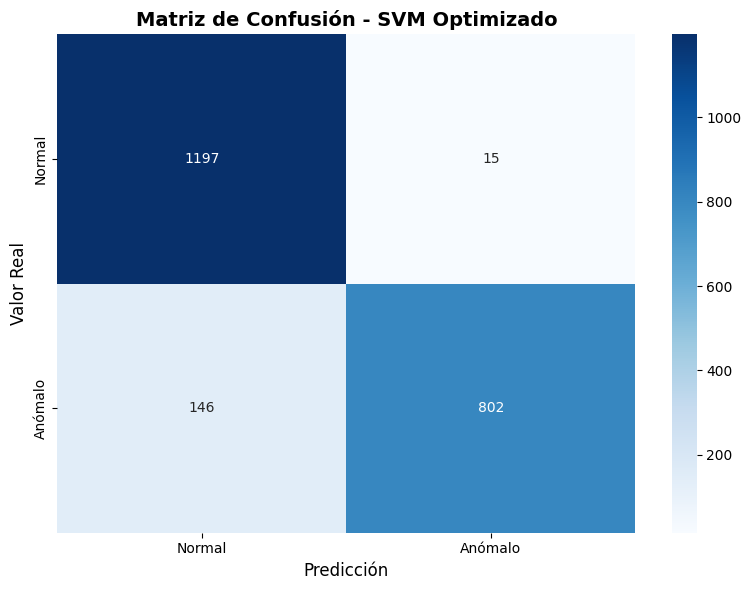


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1197 (Normal predicho correctamente)
  - Falsos Positivos (FP): 15 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 146 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 802 (Anómalo predicho correctamente)


In [16]:
# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - SVM Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm_svm.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

## 6. Modelo 2: XGBoost

### 6.1 Modelo base (sin optimización)

In [17]:
# Entrenar XGBoost con parámetros por defecto
xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
xgb_base.fit(X_train, y_train)  # XGBoost no requiere escalado

# Predicciones
y_pred_xgb_base = xgb_base.predict(X_test)
y_pred_proba_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

# Métricas
print("RESULTADOS XGBOOST BASE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb_base, target_names=['Normal', 'Anómalo']))

RESULTADOS XGBOOST BASE
Accuracy: 0.9898
Precision: 0.9894
Recall: 0.9873
F1-Score: 0.9884
ROC-AUC: 0.9983

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 6.2 Optimización con Grid Search

Hiperparámetros importantes de XGBoost:
- n_estimators: Número de árboles
- max_depth: Profundidad máxima de los árboles
- learning_rate: Tasa de aprendizaje
- subsample: Fracción de muestras para cada árbol
- colsample_bytree: Fracción de features para cada árbol

In [18]:
# Definir la grilla de hiperparámetros
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

print("Grilla de hiperparámetros para XGBoost:")
print(param_grid_xgb)
print(f"\nTotal de combinaciones: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['subsample']) * len(param_grid_xgb['colsample_bytree'])}")

Grilla de hiperparámetros para XGBoost:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7, 9], 'learning_rate': [0.01, 0.1, 0.3], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0]}

Total de combinaciones: 324


In [19]:
cv_strategy = 5 #Es para usar 5-fold CV, aunque se puede ajustar a 3 para mayor velocidad si es necesario
# Configurar Grid Search para XGBoost
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Usar la misma muestra que con SVM
X_train_xgb_sample, _, y_train_xgb_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Grid Search con muestra
grid_search_xgb.fit(X_train_xgb_sample, y_train_xgb_sample)
print("\nGrid Search completado")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Grid Search completado


In [20]:
# Mejores hiperparámetros encontrados
print("MEJORES HIPERPARÁMETROS XGBOOST")
print(f"Mejores parámetros: {grid_search_xgb.best_params_}")
print(f"Mejor F1-score (validación cruzada): {grid_search_xgb.best_score_:.4f}")

# Modelo final con todos los datos
xgb_best = XGBClassifier(
    n_estimators=grid_search_xgb.best_params_['n_estimators'],
    max_depth=grid_search_xgb.best_params_['max_depth'],
    learning_rate=grid_search_xgb.best_params_['learning_rate'],
    subsample=grid_search_xgb.best_params_['subsample'],
    colsample_bytree=grid_search_xgb.best_params_['colsample_bytree'],
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_best.fit(X_train, y_train)

MEJORES HIPERPARÁMETROS XGBOOST
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
Mejor F1-score (validación cruzada): 0.9895


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [21]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgb_best = xgb_best.predict(X_test)
y_pred_proba_xgb_best = xgb_best.predict_proba(X_test)[:, 1]

print("RESULTADOS XGBOOST OPTIMIZADO (TEST SET)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb_best, target_names=['Normal', 'Anómalo']))

RESULTADOS XGBOOST OPTIMIZADO (TEST SET)
Accuracy: 0.9907
Precision: 0.9895
Recall: 0.9895
F1-Score: 0.9895
ROC-AUC: 0.9990

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 6.3 Matriz de confusión XGBoost

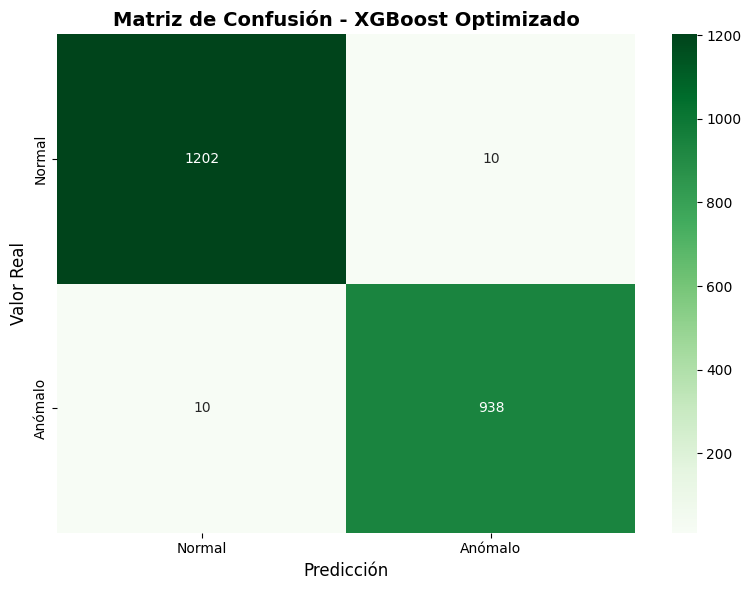


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1202 (Normal predicho correctamente)
  - Falsos Positivos (FP): 10 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 10 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 938 (Anómalo predicho correctamente)


In [22]:
# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - XGBoost Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm_xgb.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

### 6.4 Importancia de features (XGBoost)

In [23]:
# Obtener importancia de features
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("Importancia de features (XGBoost):")
print(feature_importance_xgb)

Importancia de features (XGBoost):
                            feature  importance
8                Usage_Deviation(%)    0.626184
7                Actual_Energy(kwh)    0.258874
9           Cluster_Avg_Energy(kwh)    0.051351
15          Dwelling_Type_Apartment    0.010048
6              Expected_Energy(kwh)    0.008709
0                     Num_Occupants    0.006964
13            Region_Code_IN_KL_ERN    0.006661
3                Connected_Load(kw)    0.006188
5                      Humidity (%)    0.005138
4                     Temperature_C    0.005094
2                   Appliance_Score    0.003867
16  Dwelling_Type_Independent House    0.003674
1                 House_Area (sqft)    0.003341
12            Region_Code_IN_KL_ALP    0.003028
14            Region_Code_IN_KL_TVM    0.000880
11                             Year    0.000000
10                            Month    0.000000
17              Dwelling_Type_Villa    0.000000



## 7. Modelo 3: K-Nearest Neighbors (KNN)

### 7.1 Modelo base (sin optimización)

In [24]:
import time
# KNN base con k=5 y Ball Tree para eficiencia
t0 = time.time()

knn_base = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='ball_tree',
    n_jobs=-1
)
knn_base.fit(X_train_scaled, y_train)

print(f"Tiempo de entrenamiento: {time.time()-t0:.2f}s")

#Predicciones
y_pred_knn_base       = knn_base.predict(X_test_scaled)
y_pred_proba_knn_base = knn_base.predict_proba(X_test_scaled)[:, 1]

print("\nRESULTADOS KNN BASE")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_knn_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn_base, target_names=['Normal', 'Anómalo']))

print(f"Numero de vecinos:  {knn_base.n_neighbors}")

Tiempo de entrenamiento: 0.11s

RESULTADOS KNN BASE
Accuracy:  0.8583
Precision: 0.9471
Recall:    0.7173
F1-Score:  0.8163
ROC-AUC:   0.8924

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.81      0.97      0.88      1212
     Anómalo       0.95      0.72      0.82       948

    accuracy                           0.86      2160
   macro avg       0.88      0.84      0.85      2160
weighted avg       0.87      0.86      0.85      2160

Numero de vecinos:  5


### 7.2 Optimización con RandomizedSearchCV

Se usa RandomizedSearchCV en lugar de GridSearchCV porque el espacio de hiperparámetros de KNN es amplio. Se entrena sobre una muestra estratificada del 30 % del conjunto de entrenamiento, igual que se hizo con SVM.

In [25]:
# Muestra estratificada 30 % para la búsqueda (misma estrategia que SVM)
X_train_knn_sample, _, y_train_knn_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Dataset entrenamiento completo: {len(X_train_scaled):,} muestras")
print(f"Muestra para búsqueda:          {len(X_train_knn_sample):,} muestras (30 %)")

Dataset entrenamiento completo: 8,640 muestras
Muestra para búsqueda:          2,592 muestras (30 %)


In [26]:
# Espacio de hiperparámetros
param_dist_knn = {
    'n_neighbors': randint(3, 31),                          # k entre 3 y 30
    'weights'    : ['uniform', 'distance'],                 # peso uniforme vs inverso de distancia
    'metric'     : ['euclidean', 'manhattan', 'minkowski'], # métricas de distancia
    'algorithm'  : ['ball_tree', 'kd_tree'],                # algoritmos de índice espacial
    'leaf_size'  : randint(20, 51),                         # tamaño de hoja para el árbol
    'p'          : [1, 2]                                   # Minkowski: 1=Manhattan, 2=Euclidean
}

print("Grilla de hiperparámetros para KNN:")
for k, v in param_dist_knn.items():
    print(f"  {k}: {v}")
print("\nRandomizedSearchCV explorará 30 combinaciones aleatorias")
print("Con 3-fold CV -> 90 entrenamientos sobre la muestra (30 %)")

Grilla de hiperparámetros para KNN:
  n_neighbors: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000026F8ADC1F70>
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan', 'minkowski']
  algorithm: ['ball_tree', 'kd_tree']
  leaf_size: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000026F8C4752B0>
  p: [1, 2]

RandomizedSearchCV explorará 30 combinaciones aleatorias
Con 3-fold CV -> 90 entrenamientos sobre la muestra (30 %)


In [27]:
cv_strategy_knn = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

random_search_knn = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=30,
    cv=cv_strategy_knn,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

t0 = time.time()
random_search_knn.fit(X_train_knn_sample, y_train_knn_sample)
print(f"\n Búsqueda completada en {(time.time()-t0)/60:.1f} min")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

 Búsqueda completada en 0.1 min


In [28]:
print("MEJORES HIPERPARÁMETROS KNN")
for param, value in random_search_knn.best_params_.items():
    print(f"  {param:20s}: {value}")
print(f"\n  Mejor F1 (CV): {random_search_knn.best_score_:.4f}")

MEJORES HIPERPARÁMETROS KNN
  algorithm           : kd_tree
  leaf_size           : 36
  metric              : manhattan
  n_neighbors         : 10
  p                   : 2
  weights             : distance

  Mejor F1 (CV): 0.7982


In [29]:
# Entrenar modelo final con dataset completo
t0 = time.time()

knn_best = KNeighborsClassifier(
    **random_search_knn.best_params_,
    n_jobs=-1
)
knn_best.fit(X_train_scaled, y_train)

print(f"Modelo entrenado con {len(X_train_scaled):,} muestras en {time.time()-t0:.2f}s")

Modelo entrenado con 8,640 muestras en 0.02s


### 7.3 Evaluación del KNN optimizado

In [30]:
y_pred_knn_best       = knn_best.predict(X_test_scaled)
y_pred_proba_knn_best = knn_best.predict_proba(X_test_scaled)[:, 1]

print("RESULTADOS KNN OPTIMIZADO (TEST SET)")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_knn_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn_best, target_names=['Normal', 'Anómalo']))

RESULTADOS KNN OPTIMIZADO (TEST SET)
Accuracy:  0.8593
Precision: 0.9653
Recall:    0.7046
F1-Score:  0.8146
ROC-AUC:   0.9145

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.81      0.98      0.89      1212
     Anómalo       0.97      0.70      0.81       948

    accuracy                           0.86      2160
   macro avg       0.89      0.84      0.85      2160
weighted avg       0.88      0.86      0.85      2160



### 7.4 Matriz de confusión KNN

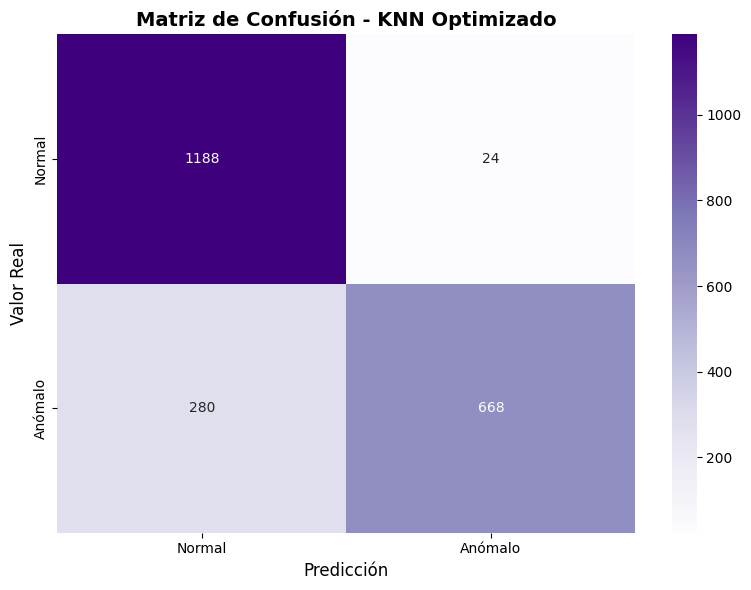


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1188 (Normal predicho correctamente)
  - Falsos Positivos (FP): 24 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 280 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 668 (Anómalo predicho correctamente)


In [31]:
cm_knn = confusion_matrix(y_test, y_pred_knn_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - KNN Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_knn.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

## 8. Modelo 4: Random Forest (RF)

Se utiliza RandomizedSearchCV con n_iter=30 sobre una muestra estratificada del 30 %, el mismo patrón aplicado con KNN.

### 8.1 Modelo base (sin optimización)

In [32]:
t0 = time.time()

# Random Forest no requiere datos escalados
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)  # Se usa X_train sin escalar

print(f"Tiempo de entrenamiento: {time.time()-t0:.2f}s")

# Predicciones
y_pred_rf_base       = rf_base.predict(X_test)
y_pred_proba_rf_base = rf_base.predict_proba(X_test)[:, 1]

# Métricas
print("\nRESULTADOS RANDOM FOREST BASE")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf_base, target_names=['Normal', 'Anómalo']))

Tiempo de entrenamiento: 0.83s

RESULTADOS RANDOM FOREST BASE
Accuracy:  0.9880
Precision: 0.9883
Recall:    0.9842
F1-Score:  0.9863
ROC-AUC:   0.9994

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.98      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 8.2 Optimización con RandomizedSearchCV

Hiperparámetros a explorar:
- n_estimators: Número de árboles (más árboles = más estable, pero más lento)
- max_depth: Profundidad máxima (controla overfitting)
- min_samples_split: Mínimo de muestras para dividir un nodo
- min_samples_leaf: Mínimo de muestras en hoja (suaviza el modelo)
- max_features: Features consideradas por árbol ('sqrt' = √p, 'log2' = log₂p)

In [33]:
# Muestra estratificada 30 % que es la misma estrategia que SVM y KNN
X_train_rf_sample, _, y_train_rf_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Dataset entrenamiento completo: {len(X_train):,} muestras")
print(f"Muestra para búsqueda:          {len(X_train_rf_sample):,} muestras (30 %)")

Dataset entrenamiento completo: 8,640 muestras
Muestra para búsqueda:          2,592 muestras (30 %)


In [34]:
# Espacio de hiperparámetros
param_dist_rf = {
    'n_estimators'    : randint(100, 501),      # Entre 100 y 500 árboles
    'max_depth'       : randint(10, 31),         # Profundidad entre 10 y 30
    'min_samples_split': randint(2, 21),         # Entre 2 y 20
    'min_samples_leaf' : randint(1, 11),         # Entre 1 y 10
    'max_features'    : ['sqrt', 'log2', 0.3, 0.5]  # Subconjunto de features
}

print("Espacio de hiperparámetros para Random Forest:")
for k, v in param_dist_rf.items():
    print(f"  {k}: {v}")
print("\nRandomizedSearchCV explorará 30 combinaciones aleatorias")

Espacio de hiperparámetros para Random Forest:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000026F92782F90>
  max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000026F927952B0>
  min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000026F9276D6D0>
  min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000026F9276DE80>
  max_features: ['sqrt', 'log2', 0.3, 0.5]

RandomizedSearchCV explorará 30 combinaciones aleatorias


In [35]:
cv_strategy_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',  # Manejo automático del desbalance de clases
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=30,               # 30 combinaciones aleatorias
    cv=cv_strategy_rf,       # 5-fold estratificado
    scoring='roc_auc',       # Optimizar ROC-AUC
    refit=True,              # Reentrenar con los mejores parámetros al finalizar
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

t0 = time.time()
random_search_rf.fit(X_train_rf_sample, y_train_rf_sample)
print(f"\nBúsqueda completada en {(time.time()-t0)/60:.1f} min")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Búsqueda completada en 1.4 min


In [36]:
print("MEJORES HIPERPARÁMETROS RANDOM FOREST")
for param, value in random_search_rf.best_params_.items():
    print(f"  {param:25s}: {value}")
print(f"\n  Mejor ROC-AUC (CV): {random_search_rf.best_score_:.4f}")

MEJORES HIPERPARÁMETROS RANDOM FOREST
  max_depth                : 17
  max_features             : 0.5
  min_samples_leaf         : 2
  min_samples_split        : 7
  n_estimators             : 153

  Mejor ROC-AUC (CV): 0.9992


In [37]:
# Entrenar modelo final con TODOS los datos de entrenamiento
t0 = time.time()

rf_best = RandomForestClassifier(
    **random_search_rf.best_params_, #Es para usar los mejores hiperparámetros encontrados
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)  # Datos sin escalar — RF no lo necesita

print(f"Modelo entrenado con {len(X_train):,} muestras en {time.time()-t0:.2f}s")

Modelo entrenado con 8,640 muestras en 1.50s


### 8.3 Evaluación del Random Forest optimizado

In [38]:
y_pred_rf_best       = rf_best.predict(X_test)
y_pred_proba_rf_best = rf_best.predict_proba(X_test)[:, 1]

print("RESULTADOS RANDOM FOREST OPTIMIZADO (TEST SET)")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf_best, target_names=['Normal', 'Anómalo']))

RESULTADOS RANDOM FOREST OPTIMIZADO (TEST SET)
Accuracy:  0.9935
Precision: 0.9916
Recall:    0.9937
F1-Score:  0.9926
ROC-AUC:   0.9994

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 8.4 Matriz de confusión Random Forest

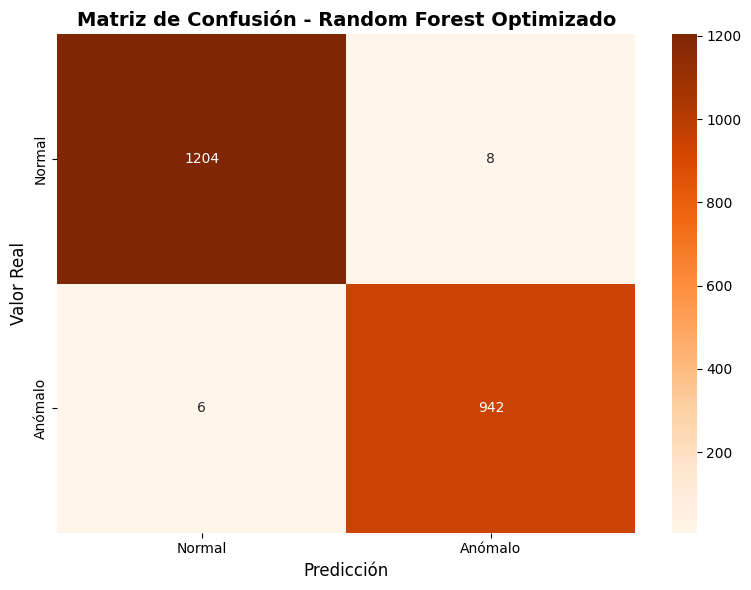


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1204 (Normal predicho correctamente)
  - Falsos Positivos (FP): 8 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 6 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 942 (Anómalo predicho correctamente)


In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - Random Forest Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

### 8.5 Importancia de features (Random Forest)

In [40]:
feature_importance_rf = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Agregar importancia acumulada
feature_importance_rf['importance_pct'] = feature_importance_rf['importance'] * 100
feature_importance_rf['cumulative_pct'] = feature_importance_rf['importance_pct'].cumsum()

print("Importancia de features — Random Forest Optimizado:")
print(feature_importance_rf.round(4).to_string(index=False))

Importancia de features — Random Forest Optimizado:
                        feature  importance  importance_pct  cumulative_pct
             Usage_Deviation(%)      0.4367         43.6721         43.6721
             Actual_Energy(kwh)      0.4334         43.3371         87.0092
           Expected_Energy(kwh)      0.0821          8.2106         95.2198
        Cluster_Avg_Energy(kwh)      0.0206          2.0633         97.2831
                  Num_Occupants      0.0056          0.5594         97.8425
                Appliance_Score      0.0045          0.4455         98.2881
             Connected_Load(kw)      0.0042          0.4183         98.7064
                  Temperature_C      0.0035          0.3457         99.0520
              House_Area (sqft)      0.0019          0.1904         99.2424
          Region_Code_IN_KL_TVM      0.0017          0.1703         99.4127
                   Humidity (%)      0.0015          0.1514         99.5641
          Region_Code_IN_KL_ERN     

In [41]:
# Guardar modelo RF
with open('modelo_rf_optimizado.pkl', 'wb') as f:
    pickle.dump(rf_best, f)
print("Modelo Random Forest guardado: modelo_rf_optimizado.pkl")

Modelo Random Forest guardado: modelo_rf_optimizado.pkl


## 9. Comparación de modelos: SVM vs XGBoost vs KNN vs Random Forest

In [42]:
# Tabla comparativa completa — 8 modelos (base + optimizado de cada algoritmo)
comparison_full_df = pd.DataFrame({
    'Modelo': [
        'SVM Base', 'SVM Optimizado',
        'XGBoost Base', 'XGBoost Optimizado',
        'KNN Base', 'KNN Optimizado',
        'RF Base', 'RF Optimizado'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm_base),  accuracy_score(y_test, y_pred_svm_best),
        accuracy_score(y_test, y_pred_xgb_base),  accuracy_score(y_test, y_pred_xgb_best),
        accuracy_score(y_test, y_pred_knn_base),  accuracy_score(y_test, y_pred_knn_best),
        accuracy_score(y_test, y_pred_rf_base),   accuracy_score(y_test, y_pred_rf_best),
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm_base),  precision_score(y_test, y_pred_svm_best),
        precision_score(y_test, y_pred_xgb_base),  precision_score(y_test, y_pred_xgb_best),
        precision_score(y_test, y_pred_knn_base),  precision_score(y_test, y_pred_knn_best),
        precision_score(y_test, y_pred_rf_base),   precision_score(y_test, y_pred_rf_best),
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm_base),  recall_score(y_test, y_pred_svm_best),
        recall_score(y_test, y_pred_xgb_base),  recall_score(y_test, y_pred_xgb_best),
        recall_score(y_test, y_pred_knn_base),  recall_score(y_test, y_pred_knn_best),
        recall_score(y_test, y_pred_rf_base),   recall_score(y_test, y_pred_rf_best),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm_base),  f1_score(y_test, y_pred_svm_best),
        f1_score(y_test, y_pred_xgb_base),  f1_score(y_test, y_pred_xgb_best),
        f1_score(y_test, y_pred_knn_base),  f1_score(y_test, y_pred_knn_best),
        f1_score(y_test, y_pred_rf_base),   f1_score(y_test, y_pred_rf_best),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_svm_base),  roc_auc_score(y_test, y_pred_proba_svm_best),
        roc_auc_score(y_test, y_pred_xgb_base),        roc_auc_score(y_test, y_pred_proba_xgb_best),
        roc_auc_score(y_test, y_pred_proba_knn_base),  roc_auc_score(y_test, y_pred_proba_knn_best),
        roc_auc_score(y_test, y_pred_proba_rf_base),   roc_auc_score(y_test, y_pred_proba_rf_best),
    ],
})

print("COMPARACIÓN COMPLETA: SVM vs XGBoost vs KNN vs Random Forest\n")
print(comparison_full_df.round(4).to_string(index=False))

best_idx = comparison_full_df['F1-Score'].idxmax()
print(f"\nMejor modelo general: {comparison_full_df.loc[best_idx, 'Modelo']}")
print(f"   F1-Score: {comparison_full_df.loc[best_idx, 'F1-Score']:.4f}")

COMPARACIÓN COMPLETA: SVM vs XGBoost vs KNN vs Random Forest

            Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
          SVM Base    0.8931     0.9786  0.7732    0.8639   0.9420
    SVM Optimizado    0.9255     0.9816  0.8460    0.9088   0.9670
      XGBoost Base    0.9898     0.9894  0.9873    0.9884   0.9895
XGBoost Optimizado    0.9907     0.9895  0.9895    0.9895   0.9990
          KNN Base    0.8583     0.9471  0.7173    0.8163   0.8924
    KNN Optimizado    0.8593     0.9653  0.7046    0.8146   0.9145
           RF Base    0.9880     0.9883  0.9842    0.9863   0.9994
     RF Optimizado    0.9935     0.9916  0.9937    0.9926   0.9994

Mejor modelo general: RF Optimizado
   F1-Score: 0.9926


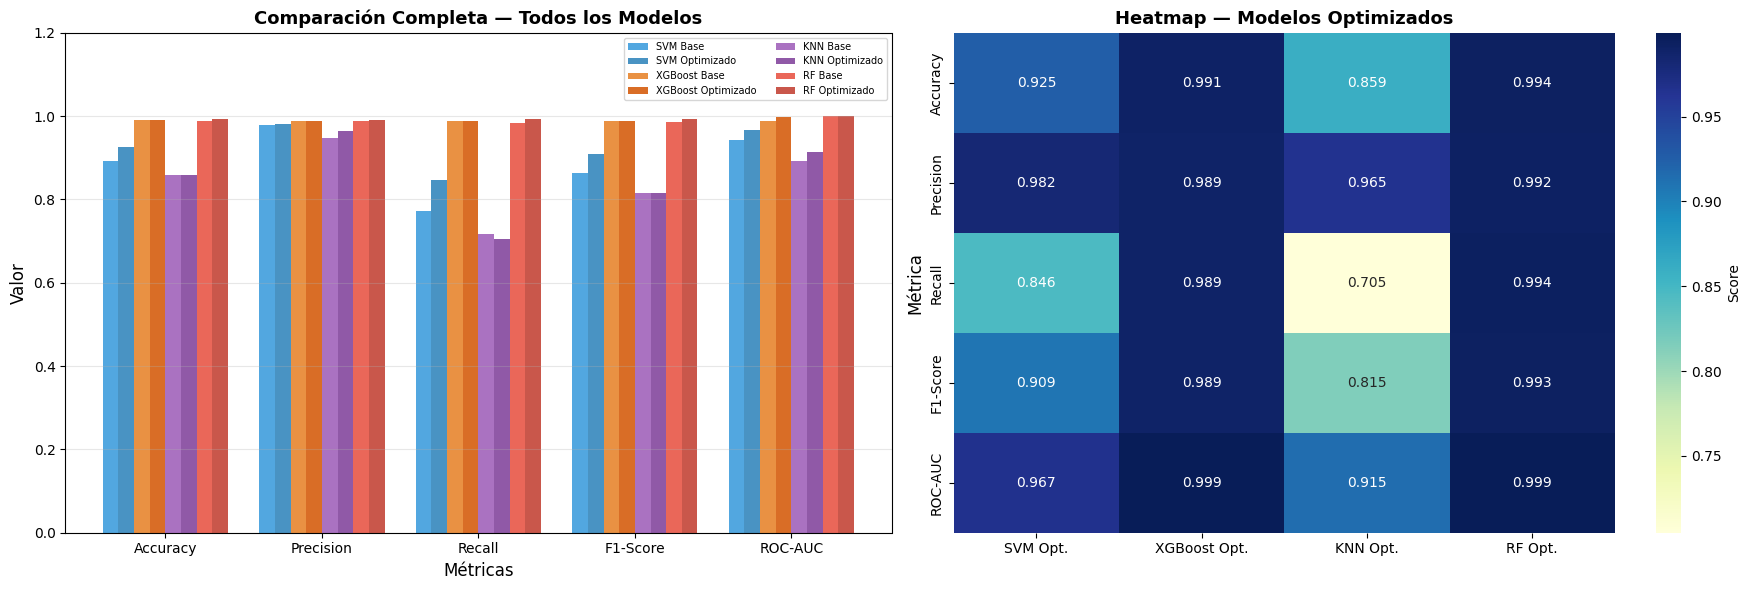

In [43]:
# Visualización comparativa
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Solo modelos optimizados para el heatmap
opt_only = comparison_full_df[comparison_full_df['Modelo'].isin(
    ['SVM Optimizado', 'XGBoost Optimizado', 'KNN Optimizado', 'RF Optimizado']
)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras — todos los modelos
x = np.arange(len(metrics))
width = 0.10
colors = ['#3498db', '#2980b9', '#e67e22', '#d35400', '#9b59b6', '#7d3c98', '#e74c3c', '#c0392b']

for i, (_, row) in enumerate(comparison_full_df.iterrows()):
    axes[0].bar(x + i*width, row[metrics].values, width,
                label=row['Modelo'], alpha=0.85, color=colors[i])

axes[0].set_xlabel('Métricas', fontsize=12)
axes[0].set_ylabel('Valor', fontsize=12)
axes[0].set_title('Comparación Completa — Todos los Modelos', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width * 3.5)
axes[0].set_xticklabels(metrics)
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.2])

# Heatmap — solo optimizados
sns.heatmap(opt_only[metrics].T.astype(float), annot=True, fmt='.3f',
            cmap='YlGnBu', cbar_kws={'label': 'Score'}, ax=axes[1],
            xticklabels=['SVM Opt.', 'XGBoost Opt.', 'KNN Opt.', 'RF Opt.'])
axes[1].set_title('Heatmap — Modelos Optimizados', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Métrica', fontsize=12)

plt.tight_layout()
plt.show()

### 9.1 Curvas ROC — SVM vs XGBoost vs KNN vs Random Forest

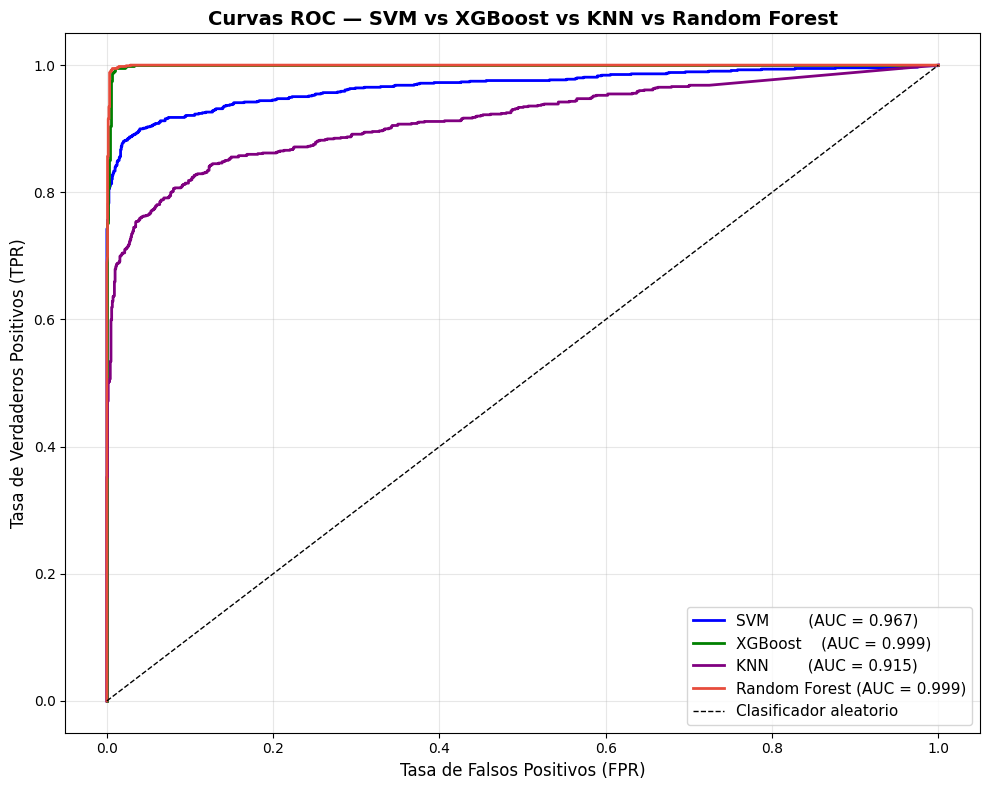

In [44]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm_best)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb_best)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn_best)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_pred_proba_rf_best)

plt.figure(figsize=(10, 8))
plt.plot(fpr_svm, tpr_svm,
         label=f'SVM        (AUC = {roc_auc_score(y_test, y_pred_proba_svm_best):.3f})',
         linewidth=2, color='blue')
plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost    (AUC = {roc_auc_score(y_test, y_pred_proba_xgb_best):.3f})',
         linewidth=2, color='green')
plt.plot(fpr_knn, tpr_knn,
         label=f'KNN        (AUC = {roc_auc_score(y_test, y_pred_proba_knn_best):.3f})',
         linewidth=2, color='purple')
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf_best):.3f})',
         linewidth=2, color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC — SVM vs XGBoost vs KNN vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Selección de Características y Validación Cruzada — SVM

Se aplica selección hacia adelante (Forward Feature Selection) para identificar el subconjunto óptimo de features,
seguida de validación cruzada estratificada con 5 folds para evaluar ambas versiones del modelo:
- SVM con todas las features
- SVM con las features seleccionadas

### 10.1 SVM — Selección Hacia Adelante (Forward Feature Selection)

Se entrena el `SequentialFeatureSelector` con el `svm_best` ya optimizado como estimador base.
En lugar de fijar un número de features de antemano, se **explora de 1 a 14** y se grafica la curva de F1-score para identificar el punto óptimo (el "codo" de la curva).

In [45]:
from sklearn.feature_selection import SequentialFeatureSelector

n_features_total = X_train_scaled.shape[1]
print(f"Total de features disponibles: {n_features_total}")

Total de features disponibles: 18


In [46]:
import time

features_disponibles   = list(X_train_scaled.columns)
features_seleccionadas = []
resultados_fs          = []

print(f"Explorando Forward Selection (1 a {n_features_total} features)...")
print(f"Entrenamientos estimados: ~{sum(range(1, n_features_total+1))} × 3 folds = {sum(range(1, n_features_total+1))*3}\n")

for paso in range(1, n_features_total + 1):
    mejor_f1       = -1
    mejor_feature  = None
    t0             = time.time()

    # Evaluar cada feature candidata (solo las que aún no entraron)
    for candidata in features_disponibles:
        features_a_probar = features_seleccionadas + [candidata]

        X_tr = X_train_scaled[features_a_probar]

        svm_temp = SVC(
            **grid_search_svm.best_params_,
            random_state = RANDOM_STATE,
            probability  = True
        )

        f1_cv = cross_val_score(
            svm_temp, X_tr, y_train,
            cv      = 3,
            scoring = 'f1',
            n_jobs  = -1
        ).mean()

        if f1_cv > mejor_f1:
            mejor_f1      = f1_cv
            mejor_feature = candidata

    # Confirmar la mejor feature de este paso
    features_seleccionadas.append(mejor_feature)
    features_disponibles.remove(mejor_feature)

    resultados_fs.append({
        'n_features'      : paso,
        'feature_agregada': mejor_feature,
        'features'        : features_seleccionadas.copy(),
        'f1'              : mejor_f1
    })

    print(f"[{paso:2d}/{n_features_total}] +'{mejor_feature}'  ->  F1 (CV): {mejor_f1:.4f}  "
          f"|  {features_seleccionadas}  ({time.time()-t0:.1f}s)")

df_curva = pd.DataFrame(resultados_fs)
print("\n¡Selección completada!")

Explorando Forward Selection (1 a 18 features)...
Entrenamientos estimados: ~171 × 3 folds = 513

[ 1/18] +'Usage_Deviation(%)'  ->  F1 (CV): 0.8182  |  ['Usage_Deviation(%)']  (211.3s)
[ 2/18] +'Actual_Energy(kwh)'  ->  F1 (CV): 0.9004  |  ['Usage_Deviation(%)', 'Actual_Energy(kwh)']  (105.0s)
[ 3/18] +'Expected_Energy(kwh)'  ->  F1 (CV): 0.9401  |  ['Usage_Deviation(%)', 'Actual_Energy(kwh)', 'Expected_Energy(kwh)']  (59.8s)
[ 4/18] +'Cluster_Avg_Energy(kwh)'  ->  F1 (CV): 0.9500  |  ['Usage_Deviation(%)', 'Actual_Energy(kwh)', 'Expected_Energy(kwh)', 'Cluster_Avg_Energy(kwh)']  (36.1s)
[ 5/18] +'Month'  ->  F1 (CV): 0.9500  |  ['Usage_Deviation(%)', 'Actual_Energy(kwh)', 'Expected_Energy(kwh)', 'Cluster_Avg_Energy(kwh)', 'Month']  (47.1s)
[ 6/18] +'Year'  ->  F1 (CV): 0.9500  |  ['Usage_Deviation(%)', 'Actual_Energy(kwh)', 'Expected_Energy(kwh)', 'Cluster_Avg_Energy(kwh)', 'Month', 'Year']  (54.0s)
[ 7/18] +'Num_Occupants'  ->  F1 (CV): 0.9459  |  ['Usage_Deviation(%)', 'Actual_Ener

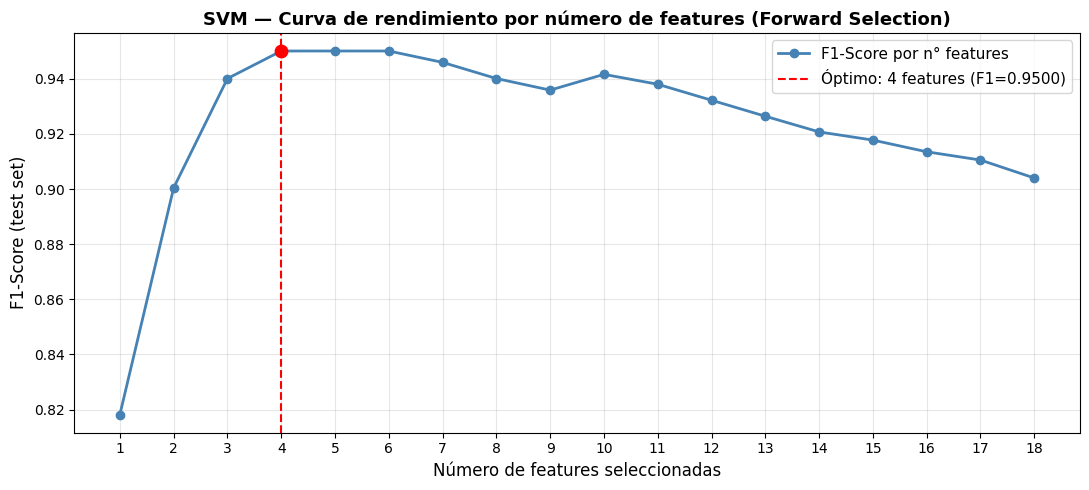

Número óptimo de features : 4
F1-Score con ese número   : 0.9500
Features seleccionadas    : ['Usage_Deviation(%)', 'Actual_Energy(kwh)', 'Expected_Energy(kwh)', 'Cluster_Avg_Energy(kwh)']


In [47]:
# Graficar la curva de rendimiento
mejor_n   = int(df_curva.loc[df_curva['f1'].idxmax(), 'n_features'])
mejor_f1  = df_curva['f1'].max()

plt.figure(figsize=(11, 5))
plt.plot(df_curva['n_features'], df_curva['f1'],
         marker='o', linewidth=2, color='steelblue', label='F1-Score por n° features')
plt.axvline(x=mejor_n, color='red', linestyle='--', linewidth=1.5,
            label=f'Óptimo: {mejor_n} features (F1={mejor_f1:.4f})')
plt.scatter([mejor_n], [mejor_f1], color='red', zorder=5, s=80)
plt.xlabel('Número de features seleccionadas', fontsize=12)
plt.ylabel('F1-Score (test set)', fontsize=12)
plt.title('SVM — Curva de rendimiento por número de features (Forward Selection)',
          fontsize=13, fontweight='bold')
plt.xticks(range(1, n_features_total + 1))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Número óptimo de features : {mejor_n}")
print(f"F1-Score con ese número   : {mejor_f1:.4f}")
print(f"Features seleccionadas    : {df_curva.loc[df_curva['f1'].idxmax(), 'features']}")

In [48]:
# Usar el número óptimo encontrado en la curva para el modelo final
n_optimo = mejor_n
features_seleccionadas_svm = df_curva.loc[df_curva['n_features'] == n_optimo, 'features'].values[0]
features_descartadas_svm   = [f for f in X_train_scaled.columns if f not in features_seleccionadas_svm]

print(f"Features SELECCIONADAS ({len(features_seleccionadas_svm)}):")
for f in features_seleccionadas_svm:
    print(f)

print(f"\nFeatures DESCARTADAS ({len(features_descartadas_svm)}):")
for f in features_descartadas_svm:
    print(f)

Features SELECCIONADAS (4):
Usage_Deviation(%)
Actual_Energy(kwh)
Expected_Energy(kwh)
Cluster_Avg_Energy(kwh)

Features DESCARTADAS (14):
Num_Occupants
House_Area (sqft)
Appliance_Score
Connected_Load(kw)
Temperature_C
Humidity (%)
Month
Year
Region_Code_IN_KL_ALP
Region_Code_IN_KL_ERN
Region_Code_IN_KL_TVM
Dwelling_Type_Apartment
Dwelling_Type_Independent House
Dwelling_Type_Villa


In [49]:
# Subconjuntos con las features óptimas
X_train_svm_fs = X_train_scaled[features_seleccionadas_svm]
X_test_svm_fs  = X_test_scaled[features_seleccionadas_svm]

# Reentrenar SVM con los hiperparámetros ya optimizados y las features seleccionadas
svm_fs = SVC(
    **grid_search_svm.best_params_,
    random_state = RANDOM_STATE,
    probability  = True
)
svm_fs.fit(X_train_svm_fs, y_train)

# Predicciones
y_pred_svm_fs       = svm_fs.predict(X_test_svm_fs)
y_pred_proba_svm_fs = svm_fs.predict_proba(X_test_svm_fs)[:, 1]

print("RESULTADOS SVM — CON SELECCIÓN HACIA ADELANTE")
print(f"Features usadas : {len(features_seleccionadas_svm)} de {n_features_total}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_svm_fs):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_svm_fs):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_svm_fs):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_svm_fs):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_proba_svm_fs):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm_fs, target_names=['Normal', 'Anómalo']))

RESULTADOS SVM — CON SELECCIÓN HACIA ADELANTE
Features usadas : 4 de 18
Accuracy  : 0.9537
Precision : 0.9930
Recall    : 0.9008
F1-Score  : 0.9447
ROC-AUC   : 0.9821

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96      1212
     Anómalo       0.99      0.90      0.94       948

    accuracy                           0.95      2160
   macro avg       0.96      0.95      0.95      2160
weighted avg       0.96      0.95      0.95      2160



In [50]:
# Comparación: SVM completo vs SVM con Forward Selection
comparacion_svm_fs = pd.DataFrame({
    'Modelo'      : ['SVM Optimizado (todas las features)', f'SVM + Forward Selection ({n_optimo} features)'],
    'N° Features' : [n_features_total, len(features_seleccionadas_svm)],
    'Accuracy'    : [accuracy_score(y_test, y_pred_svm_best),  accuracy_score(y_test, y_pred_svm_fs)],
    'Precision'   : [precision_score(y_test, y_pred_svm_best), precision_score(y_test, y_pred_svm_fs)],
    'Recall'      : [recall_score(y_test, y_pred_svm_best),    recall_score(y_test, y_pred_svm_fs)],
    'F1-Score'    : [f1_score(y_test, y_pred_svm_best),        f1_score(y_test, y_pred_svm_fs)],
    'ROC-AUC'     : [roc_auc_score(y_test, y_pred_proba_svm_best), roc_auc_score(y_test, y_pred_proba_svm_fs)]
})

print("Comparación SVM — todas las features vs Forward Selection:")
print(comparacion_svm_fs.round(4).to_string(index=False))

Comparación SVM — todas las features vs Forward Selection:
                              Modelo  N° Features  Accuracy  Precision  Recall  F1-Score  ROC-AUC
 SVM Optimizado (todas las features)           18    0.9255     0.9816  0.8460    0.9088   0.9670
SVM + Forward Selection (4 features)            4    0.9537     0.9930  0.9008    0.9447   0.9821


### 10.2 Validación cruzada — SVM con todas las features

In [51]:
from sklearn.model_selection import cross_validate

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

t0 = time.time()

cv_results_svm_completo = cross_validate(
    svm_best,
    X_train_scaled, y_train,
    cv=cv_5fold,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=True  # Permite detectar overfitting comparando train vs validación
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — SVM TODAS LAS FEATURES")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores   = cv_results_svm_completo[f'test_{metrica}']
    train_scores = cv_results_svm_completo[f'train_{metrica}']
    print(f"  {metrica:10s} | Val: {val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — SVM TODAS LAS FEATURES
  accuracy   | Val: 0.9271 ± 0.0054 | Train: 0.9495 ± 0.0014
  precision  | Val: 0.9792 ± 0.0048 | Train: 0.9932 ± 0.0005
  recall     | Val: 0.8520 ± 0.0156 | Train: 0.8910 ± 0.0035
  f1         | Val: 0.9111 ± 0.0074 | Train: 0.9393 ± 0.0018
  roc_auc    | Val: 0.9636 ± 0.0069 | Train: 0.9822 ± 0.0009

Tiempo: 14.9s


### 10.3 Validación cruzada — SVM con Forward Selection

In [52]:
t0 = time.time()
# Se realiza validación cruzada con el modelo SVM entrenado solo con las features
# seleccionadas por Forward Selection, para evaluar su rendimiento.
cv_results_svm_fs = cross_validate(
    svm_fs,
    X_train_svm_fs, y_train,
    cv=cv_5fold,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=True
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — SVM CON FORWARD SELECTION")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores   = cv_results_svm_fs[f'test_{metrica}']
    train_scores = cv_results_svm_fs[f'train_{metrica}']
    print(f"  {metrica:10s} | Val: {val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — SVM CON FORWARD SELECTION
  accuracy   | Val: 0.9591 ± 0.0059 | Train: 0.9615 ± 0.0013
  precision  | Val: 0.9929 ± 0.0026 | Train: 0.9944 ± 0.0006
  recall     | Val: 0.9135 ± 0.0149 | Train: 0.9176 ± 0.0028
  f1         | Val: 0.9514 ± 0.0074 | Train: 0.9544 ± 0.0016
  roc_auc    | Val: 0.9853 ± 0.0022 | Train: 0.9862 ± 0.0004

Tiempo: 6.4s


### 10.4 Comparación de la validación cruzada — SVM

In [53]:
metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resumen_cv_svm = pd.DataFrame({
    'Métrica'            : metricas_cv,
    'SVM_Completo_Media' : [cv_results_svm_completo[f'test_{m}'].mean() for m in metricas_cv],
    'SVM_Completo_Std'   : [cv_results_svm_completo[f'test_{m}'].std()  for m in metricas_cv],
    'SVM_FS_Media'       : [cv_results_svm_fs[f'test_{m}'].mean()       for m in metricas_cv],
    'SVM_FS_Std'         : [cv_results_svm_fs[f'test_{m}'].std()        for m in metricas_cv],
})

print("COMPARACIÓN VALIDACIÓN CRUZADA — SVM Completo vs SVM + Forward Selection")
print(resumen_cv_svm.round(4).to_string(index=False))

COMPARACIÓN VALIDACIÓN CRUZADA — SVM Completo vs SVM + Forward Selection
  Métrica  SVM_Completo_Media  SVM_Completo_Std  SVM_FS_Media  SVM_FS_Std
 accuracy              0.9271            0.0054        0.9591      0.0059
precision              0.9792            0.0048        0.9929      0.0026
   recall              0.8520            0.0156        0.9135      0.0149
       f1              0.9111            0.0074        0.9514      0.0074
  roc_auc              0.9636            0.0069        0.9853      0.0022


## 11. Selección de Características y Validación Cruzada — XGBoost

Se aplica selección por importancia de features (umbral = mean) para identificar el subconjunto relevante,
seguida de validación cruzada estratificada con 5 folds para evaluar ambas versiones del modelo:
- XGBoost con todas las features
- XGBoost con las features seleccionadas

### 11.1 XGBoost — Selección por Importancia de Features (Umbral)

XGBoost calcula internamente cuánto contribuye cada feature a reducir el error en todos los árboles (`feature_importances_`).
Se usa `SelectFromModel` con `threshold='mean'`: se conservan solo las features cuya importancia supere el promedio y se descartan el resto.
El modelo ya está entrenado (`prefit=True`), por lo que esta selección es instantánea.

In [54]:
from sklearn.feature_selection import SelectFromModel

# SelectFromModel con threshold='mean':
# conserva features con importancia >= promedio de todas las importancias
selector_xgb = SelectFromModel(
    estimator = xgb_best,
    threshold = 'mean',   # umbral = importancia promedio
    prefit    = True      # xgb_best ya está entrenado
)

# Aplicar selección a train y test
X_train_xgb_fs = selector_xgb.transform(X_train)
X_test_xgb_fs  = selector_xgb.transform(X_test)

# Identificar features seleccionadas y descartadas
features_seleccionadas_xgb = X.columns[selector_xgb.get_support()].tolist()
features_descartadas_xgb   = X.columns[~selector_xgb.get_support()].tolist()

umbral = xgb_best.feature_importances_.mean()
print(f"Umbral de importancia (promedio): {umbral:.4f}")

print(f"\nFeatures SELECCIONADAS ({len(features_seleccionadas_xgb)}):")
for f in features_seleccionadas_xgb:
    imp = xgb_best.feature_importances_[list(X.columns).index(f)]
    print(f" {f:35s}  importancia: {imp:.4f}")

print(f"\nFeatures DESCARTADAS ({len(features_descartadas_xgb)}):")
for f in features_descartadas_xgb:
    imp = xgb_best.feature_importances_[list(X.columns).index(f)]
    print(f" {f:35s}  importancia: {imp:.4f}")

Umbral de importancia (promedio): 0.0556

Features SELECCIONADAS (2):
 Actual_Energy(kwh)                   importancia: 0.2589
 Usage_Deviation(%)                   importancia: 0.6262

Features DESCARTADAS (16):
 Num_Occupants                        importancia: 0.0070
 House_Area (sqft)                    importancia: 0.0033
 Appliance_Score                      importancia: 0.0039
 Connected_Load(kw)                   importancia: 0.0062
 Temperature_C                        importancia: 0.0051
 Humidity (%)                         importancia: 0.0051
 Expected_Energy(kwh)                 importancia: 0.0087
 Cluster_Avg_Energy(kwh)              importancia: 0.0514
 Month                                importancia: 0.0000
 Year                                 importancia: 0.0000
 Region_Code_IN_KL_ALP                importancia: 0.0030
 Region_Code_IN_KL_ERN                importancia: 0.0067
 Region_Code_IN_KL_TVM                importancia: 0.0009
 Dwelling_Type_Apartment        

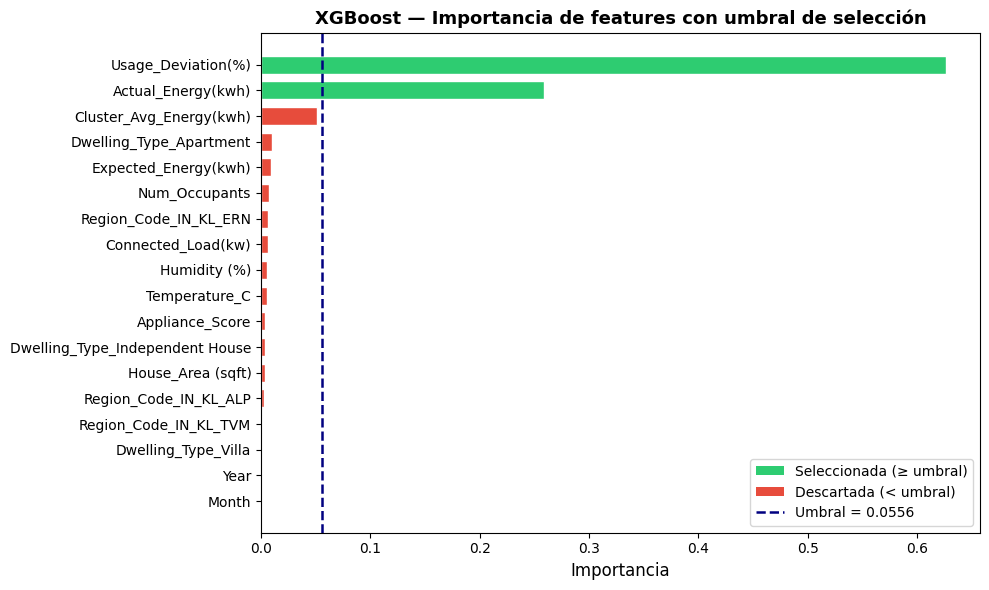

In [55]:
# Gráfica de importancias con línea de umbral
feature_imp_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=True)

colores = ['#2ecc71' if imp >= umbral else '#e74c3c'
           for imp in feature_imp_df['importance']]

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_imp_df['feature'], feature_imp_df['importance'],
                color=colores, edgecolor='white', height=0.7)
plt.axvline(x=umbral, color='navy', linestyle='--', linewidth=1.8,
            label=f'Umbral (mean = {umbral:.4f})')
plt.xlabel('Importancia', fontsize=12)
plt.title('XGBoost — Importancia de features con umbral de selección',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Seleccionada (≥ umbral)'),
                   Patch(facecolor='#e74c3c', label='Descartada (< umbral)')]
plt.legend(handles=legend_elements + [plt.Line2D([0], [0], color='navy',
           linestyle='--', linewidth=1.8, label=f'Umbral = {umbral:.4f}')],
           fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

In [56]:
# Reentrenar XGBoost con los hiperparámetros ya optimizados y las features seleccionadas
xgb_fs = XGBClassifier(
    n_estimators     = grid_search_xgb.best_params_['n_estimators'],
    max_depth        = grid_search_xgb.best_params_['max_depth'],
    learning_rate    = grid_search_xgb.best_params_['learning_rate'],
    subsample        = grid_search_xgb.best_params_['subsample'],
    colsample_bytree = grid_search_xgb.best_params_['colsample_bytree'],
    random_state     = RANDOM_STATE,
    eval_metric      = 'logloss'
)
xgb_fs.fit(X_train_xgb_fs, y_train)

# Predicciones
y_pred_xgb_fs       = xgb_fs.predict(X_test_xgb_fs)
y_pred_proba_xgb_fs = xgb_fs.predict_proba(X_test_xgb_fs)[:, 1]

print("RESULTADOS XGBOOST — CON SELECCIÓN POR IMPORTANCIA")
print(f"Features usadas : {len(features_seleccionadas_xgb)} de {n_features_total}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb_fs):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb_fs):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb_fs):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_xgb_fs):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_proba_xgb_fs):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb_fs, target_names=['Normal', 'Anómalo']))

RESULTADOS XGBOOST — CON SELECCIÓN POR IMPORTANCIA
Features usadas : 2 de 18
Accuracy  : 0.9718
Precision : 0.9733
Recall    : 0.9620
F1-Score  : 0.9676
ROC-AUC   : 0.9966

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97      1212
     Anómalo       0.97      0.96      0.97       948

    accuracy                           0.97      2160
   macro avg       0.97      0.97      0.97      2160
weighted avg       0.97      0.97      0.97      2160



In [57]:
# Comparación: XGBoost completo vs XGBoost con selección por importancia
comparacion_xgb_fs = pd.DataFrame({
    'Modelo'      : ['XGBoost Optimizado (todas las features)',
                     f'XGBoost + Importancia ({len(features_seleccionadas_xgb)} features, umbral=mean)'],
    'N° Features' : [n_features_total, len(features_seleccionadas_xgb)],
    'Accuracy'    : [accuracy_score(y_test, y_pred_xgb_best),  accuracy_score(y_test, y_pred_xgb_fs)],
    'Precision'   : [precision_score(y_test, y_pred_xgb_best), precision_score(y_test, y_pred_xgb_fs)],
    'Recall'      : [recall_score(y_test, y_pred_xgb_best),    recall_score(y_test, y_pred_xgb_fs)],
    'F1-Score'    : [f1_score(y_test, y_pred_xgb_best),        f1_score(y_test, y_pred_xgb_fs)],
    'ROC-AUC'     : [roc_auc_score(y_test, y_pred_proba_xgb_best), roc_auc_score(y_test, y_pred_proba_xgb_fs)]
})

print("Comparación XGBoost — todas las features vs Selección por Importancia:")
print(comparacion_xgb_fs.round(4).to_string(index=False))

Comparación XGBoost — todas las features vs Selección por Importancia:
                                         Modelo  N° Features  Accuracy  Precision  Recall  F1-Score  ROC-AUC
        XGBoost Optimizado (todas las features)           18    0.9907     0.9895  0.9895    0.9895   0.9990
XGBoost + Importancia (2 features, umbral=mean)            2    0.9718     0.9733  0.9620    0.9676   0.9966


### 11.2 Validación cruzada — XGBoost con todas las features

In [58]:
t0 = time.time()

cv_results_xgb_completo = cross_validate(
    xgb_best,
    X_train, y_train,          # XGBoost no requiere datos escalados
    cv=cv_5fold,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=True    # Permite detectar overfitting comparando train vs validación
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — XGBOOST TODAS LAS FEATURES")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores   = cv_results_xgb_completo[f'test_{metrica}']
    train_scores = cv_results_xgb_completo[f'train_{metrica}']
    print(f"  {metrica:10s} | Val: {val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — XGBOOST TODAS LAS FEATURES
  accuracy   | Val: 0.9933 ± 0.0022 | Train: 0.9999 ± 0.0002
  precision  | Val: 0.9898 ± 0.0051 | Train: 0.9997 ± 0.0004
  recall     | Val: 0.9950 ± 0.0027 | Train: 1.0000 ± 0.0000
  f1         | Val: 0.9924 ± 0.0025 | Train: 0.9998 ± 0.0002
  roc_auc    | Val: 0.9996 ± 0.0003 | Train: 1.0000 ± 0.0000

Tiempo: 0.4s


### 11.3 Validación cruzada — XGBoost con Selección por Importancia

In [59]:
t0 = time.time()
# Se realiza validación cruzada con el modelo XGBoost entrenado solo con las features
# seleccionadas por importancia (umbral = mean), para evaluar su rendimiento.
cv_results_xgb_fs = cross_validate(
    xgb_fs,
    X_train_xgb_fs, y_train,   # Subconjunto ya transformado por SelectFromModel
    cv=cv_5fold,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=True
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — XGBOOST CON SELECCIÓN POR IMPORTANCIA")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores   = cv_results_xgb_fs[f'test_{metrica}']
    train_scores = cv_results_xgb_fs[f'train_{metrica}']
    print(f"  {metrica:10s} | Val: {val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — XGBOOST CON SELECCIÓN POR IMPORTANCIA
  accuracy   | Val: 0.9740 ± 0.0025 | Train: 0.9854 ± 0.0016
  precision  | Val: 0.9722 ± 0.0053 | Train: 0.9867 ± 0.0036
  recall     | Val: 0.9683 ± 0.0029 | Train: 0.9799 ± 0.0009
  f1         | Val: 0.9703 ± 0.0027 | Train: 0.9833 ± 0.0018
  roc_auc    | Val: 0.9974 ± 0.0005 | Train: 0.9992 ± 0.0002

Tiempo: 0.2s


### 11.4 Comparación de la validación cruzada — XGBoost

In [60]:
metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resumen_cv_xgb = pd.DataFrame({
    'Métrica'              : metricas_cv,
    'XGB_Completo_Media'   : [cv_results_xgb_completo[f'test_{m}'].mean() for m in metricas_cv],
    'XGB_Completo_Std'     : [cv_results_xgb_completo[f'test_{m}'].std()  for m in metricas_cv],
    'XGB_FS_Media'         : [cv_results_xgb_fs[f'test_{m}'].mean()       for m in metricas_cv],
    'XGB_FS_Std'           : [cv_results_xgb_fs[f'test_{m}'].std()        for m in metricas_cv],
})

print("COMPARACIÓN VALIDACIÓN CRUZADA — XGBoost Completo vs XGBoost + Importancia")
print(resumen_cv_xgb.round(4).to_string(index=False))

COMPARACIÓN VALIDACIÓN CRUZADA — XGBoost Completo vs XGBoost + Importancia
  Métrica  XGB_Completo_Media  XGB_Completo_Std  XGB_FS_Media  XGB_FS_Std
 accuracy              0.9933            0.0022        0.9740      0.0025
precision              0.9898            0.0051        0.9722      0.0053
   recall              0.9950            0.0027        0.9683      0.0029
       f1              0.9924            0.0025        0.9703      0.0027
  roc_auc              0.9996            0.0003        0.9974      0.0005


## 12. Selección de Características y Validación Cruzada — KNN


### 12.1 KNN — Selección de Variables con RFE (curva de rendimiento)

Se aplica el mismo método de curva de rendimiento usado con SVM (Forward Selection), pero usando el `knn_best` ya optimizado como estimador base.

En lugar de fijar un número de features de antemano, se explora de 1 a n_features y se grafica la curva de F1-score para identificar el punto óptimo (el "codo" de la curva).

In [61]:
n_features_total = X_train_scaled.shape[1]
print(f"Total de features disponibles: {n_features_total}")

#Se hace una muestra estratificada del 30 % para la selección de features con RFE en KNN, usando la misma estrategia que SVM y RF
X_rfe_knn_sample, _, y_rfe_knn_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_train
)
print(f"Muestra para RFE KNN: {X_rfe_knn_sample.shape[0]:,} muestras (30 %)")


Total de features disponibles: 18
Muestra para RFE KNN: 2,592 muestras (30 %)


In [62]:
# Parámetros del knn_best sin n_jobs porque RFE hace muchos entrenamientos secuenciales y no queremos que cada uno intente usar todos los núcleos
knn_params_rfe = {k: v for k, v in knn_best.get_params().items() if k != 'n_jobs'}

features_disponibles_knn   = list(X_train_scaled.columns)
features_seleccionadas_knn = []
resultados_rfe_knn         = []

print(f"Explorando Forward Selection con KNN (1 a {n_features_total} features)...")
print(f"Entrenamientos estimados: {sum(range(1, n_features_total+1))} × 3 folds\n")

#El for lo que hace es ir agregando una feature por paso, probando cada una de las features disponibles
#y quedándose con la que da el mejor F1-Score en CV.
for paso in range(1, n_features_total + 1):
    mejor_f1      = -1
    mejor_feature = None
    t0            = time.time()

    for candidata in features_disponibles_knn:
        features_a_probar = features_seleccionadas_knn + [candidata]

        X_tr = X_rfe_knn_sample[features_a_probar]

        knn_temp = KNeighborsClassifier(**knn_params_rfe)

        f1_cv = cross_val_score(
            knn_temp, X_tr, y_rfe_knn_sample,
            cv=3,
            scoring='f1',
            n_jobs=-1
        ).mean()

        if f1_cv > mejor_f1:
            mejor_f1      = f1_cv
            mejor_feature = candidata

    features_seleccionadas_knn.append(mejor_feature)
    features_disponibles_knn.remove(mejor_feature)

    resultados_rfe_knn.append({
        'n_features'      : paso,
        'feature_agregada': mejor_feature,
        'features'        : features_seleccionadas_knn.copy(),
        'f1'              : mejor_f1
    })

    print(f"[{paso:2d}/{n_features_total}] +'{mejor_feature}'  -  F1 (CV): {mejor_f1:.4f}  "
          f"|  {features_seleccionadas_knn}  ({time.time()-t0:.1f}s)")

df_curva_knn = pd.DataFrame(resultados_rfe_knn)
print("\n¡Selección completada!")


Explorando Forward Selection con KNN (1 a 18 features)...
Entrenamientos estimados: 171 × 3 folds



[ 1/18] +'Actual_Energy(kwh)'  -  F1 (CV): 0.8462  |  ['Actual_Energy(kwh)']  (0.7s)
[ 2/18] +'Usage_Deviation(%)'  -  F1 (CV): 0.9514  |  ['Actual_Energy(kwh)', 'Usage_Deviation(%)']  (0.5s)
[ 3/18] +'Month'  -  F1 (CV): 0.9514  |  ['Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Month']  (0.6s)
[ 4/18] +'Year'  -  F1 (CV): 0.9514  |  ['Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Month', 'Year']  (0.5s)
[ 5/18] +'Region_Code_IN_KL_ERN'  -  F1 (CV): 0.9500  |  ['Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Month', 'Year', 'Region_Code_IN_KL_ERN']  (0.6s)
[ 6/18] +'Region_Code_IN_KL_ALP'  -  F1 (CV): 0.9459  |  ['Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Month', 'Year', 'Region_Code_IN_KL_ERN', 'Region_Code_IN_KL_ALP']  (0.5s)
[ 7/18] +'Region_Code_IN_KL_TVM'  -  F1 (CV): 0.9459  |  ['Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Month', 'Year', 'Region_Code_IN_KL_ERN', 'Region_Code_IN_KL_ALP', 'Region_Code_IN_KL_TVM']  (0.5s)
[ 8/18] +'Dwelling_Type_Villa'  -  F1 (CV): 0.9299  |  ['Actual_

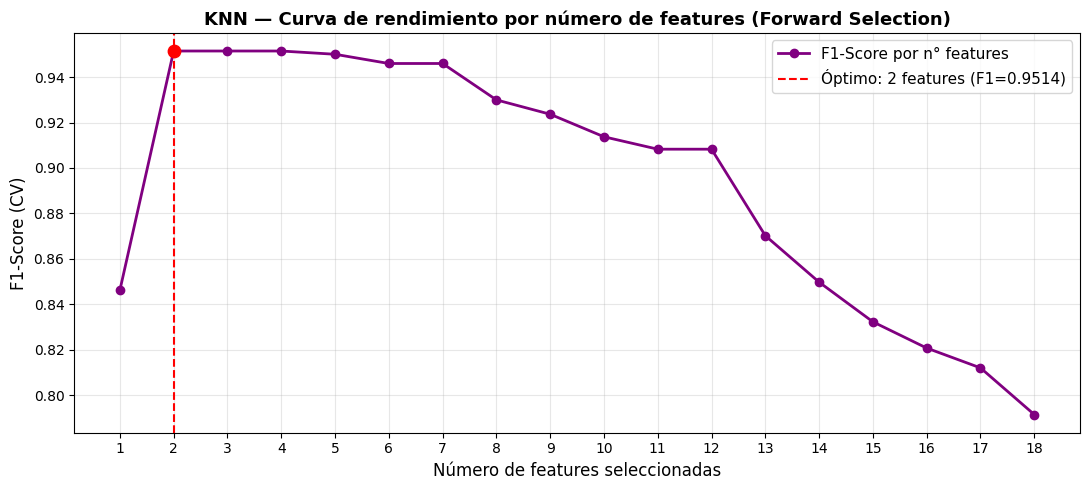

Número óptimo de features : 2
F1-Score con ese número   : 0.9514
Features seleccionadas    : ['Actual_Energy(kwh)', 'Usage_Deviation(%)']


In [63]:
#Se grafica la curva de rendimiento del F1-Score en función del número de features seleccionadas.
mejor_n_knn  = int(df_curva_knn.loc[df_curva_knn['f1'].idxmax(), 'n_features'])
mejor_f1_knn = df_curva_knn['f1'].max()

plt.figure(figsize=(11, 5))
plt.plot(df_curva_knn['n_features'], df_curva_knn['f1'],
         marker='o', linewidth=2, color='purple', label='F1-Score por n° features')
plt.axvline(x=mejor_n_knn, color='red', linestyle='--', linewidth=1.5,
            label=f'Óptimo: {mejor_n_knn} features (F1={mejor_f1_knn:.4f})')
plt.scatter([mejor_n_knn], [mejor_f1_knn], color='red', zorder=5, s=80)
plt.xlabel('Número de features seleccionadas', fontsize=12)
plt.ylabel('F1-Score (CV)', fontsize=12)
plt.title('KNN — Curva de rendimiento por número de features (Forward Selection)',
          fontsize=13, fontweight='bold')
plt.xticks(range(1, n_features_total + 1))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Número óptimo de features : {mejor_n_knn}")
print(f"F1-Score con ese número   : {mejor_f1_knn:.4f}")
print(f"Features seleccionadas    : {df_curva_knn.loc[df_curva_knn['f1'].idxmax(), 'features']}")


In [64]:
#Se toma el número óptimo de features encontrado en la curva para el modelo final de KNN, y se ven cuáles son las features seleccionadas y descartadas.
n_optimo_knn                   = mejor_n_knn
features_seleccionadas_knn_opt = df_curva_knn.loc[df_curva_knn['n_features'] == n_optimo_knn, 'features'].values[0]
features_descartadas_knn       = [f for f in X_train_scaled.columns if f not in features_seleccionadas_knn_opt]

print(f"Features SELECCIONADAS ({len(features_seleccionadas_knn_opt)}):")
for f in features_seleccionadas_knn_opt:
    print(f"  {f}")

print(f"\nFeatures DESCARTADAS ({len(features_descartadas_knn)}):")
for f in features_descartadas_knn:
    print(f"  {f}")


Features SELECCIONADAS (2):
  Actual_Energy(kwh)
  Usage_Deviation(%)

Features DESCARTADAS (16):
  Num_Occupants
  House_Area (sqft)
  Appliance_Score
  Connected_Load(kw)
  Temperature_C
  Humidity (%)
  Expected_Energy(kwh)
  Cluster_Avg_Energy(kwh)
  Month
  Year
  Region_Code_IN_KL_ALP
  Region_Code_IN_KL_ERN
  Region_Code_IN_KL_TVM
  Dwelling_Type_Apartment
  Dwelling_Type_Independent House
  Dwelling_Type_Villa


In [65]:
# Subconjuntos con las features óptimas
X_train_knn_fs = X_train_scaled[features_seleccionadas_knn_opt]
X_test_knn_fs  = X_test_scaled[features_seleccionadas_knn_opt]

#Se reentrena el modelo KNN con los hiperparámetros ya optimizados y las features seleccionadas por RFE.
knn_fs = KNeighborsClassifier(**knn_best.get_params())
knn_fs.fit(X_train_knn_fs, y_train)

#Se hacen las predicciones con el modelo KNN entrenado solo con las features seleccionadas por RFE, y se calculan las métricas de rendimiento.
y_pred_knn_fs       = knn_fs.predict(X_test_knn_fs)
y_pred_proba_knn_fs = knn_fs.predict_proba(X_test_knn_fs)[:, 1]

print("RESULTADOS KNN — CON SELECCIÓN FORWARD (RFE)")
print(f"Features usadas : {len(features_seleccionadas_knn_opt)} de {n_features_total}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_knn_fs):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_knn_fs):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_knn_fs):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_knn_fs):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_proba_knn_fs):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn_fs, target_names=['Normal', 'Anómalo']))


RESULTADOS KNN — CON SELECCIÓN FORWARD (RFE)
Features usadas : 2 de 18
Accuracy  : 0.9579
Precision : 0.9413
Recall    : 0.9641
F1-Score  : 0.9526
ROC-AUC   : 0.9896

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96      1212
     Anómalo       0.94      0.96      0.95       948

    accuracy                           0.96      2160
   macro avg       0.96      0.96      0.96      2160
weighted avg       0.96      0.96      0.96      2160



In [66]:
# Comparación: KNN completo vs KNN con Forward Selection
comparacion_knn_fs = pd.DataFrame({
    'Modelo'      : ['KNN Optimizado (todas las features)',
                     f'KNN + Forward Selection ({n_optimo_knn} features)'],
    'N° Features' : [n_features_total, len(features_seleccionadas_knn_opt)],
    'Accuracy'    : [accuracy_score(y_test, y_pred_knn_best),  accuracy_score(y_test, y_pred_knn_fs)],
    'Precision'   : [precision_score(y_test, y_pred_knn_best), precision_score(y_test, y_pred_knn_fs)],
    'Recall'      : [recall_score(y_test, y_pred_knn_best),    recall_score(y_test, y_pred_knn_fs)],
    'F1-Score'    : [f1_score(y_test, y_pred_knn_best),        f1_score(y_test, y_pred_knn_fs)],
    'ROC-AUC'     : [roc_auc_score(y_test, y_pred_proba_knn_best), roc_auc_score(y_test, y_pred_proba_knn_fs)]
})

print("Comparación KNN — todas las features vs Forward Selection:")
print(comparacion_knn_fs.round(4).to_string(index=False))


Comparación KNN — todas las features vs Forward Selection:
                              Modelo  N° Features  Accuracy  Precision  Recall  F1-Score  ROC-AUC
 KNN Optimizado (todas las features)           18    0.8593     0.9653  0.7046    0.8146   0.9145
KNN + Forward Selection (2 features)            2    0.9579     0.9413  0.9641    0.9526   0.9896


### 12.2 Validación cruzada — KNN con todas las features

In [67]:
from sklearn.model_selection import cross_validate

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

t0 = time.time()

cv_results_knn_completo = cross_validate(
    knn_best,
    X_train_scaled, y_train,
    cv=cv_5fold,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=True  # Permite detectar overfitting comparando train vs validación
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — KNN TODAS LAS FEATURES")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores   = cv_results_knn_completo[f'test_{metrica}']
    train_scores = cv_results_knn_completo[f'train_{metrica}']
    print(f"  {metrica:10s} | Val: {val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")



RESULTADOS VALIDACIÓN CRUZADA — KNN TODAS LAS FEATURES
  accuracy   | Val: 0.8703 ± 0.0093 | Train: 1.0000 ± 0.0000
  precision  | Val: 0.9596 ± 0.0069 | Train: 1.0000 ± 0.0000
  recall     | Val: 0.7352 ± 0.0172 | Train: 1.0000 ± 0.0000
  f1         | Val: 0.8325 ± 0.0133 | Train: 1.0000 ± 0.0000
  roc_auc    | Val: 0.9258 ± 0.0143 | Train: 1.0000 ± 0.0000


### 12.3 Validación cruzada — KNN con Forward Selection

In [68]:
t0 = time.time()
#Se realiza validación cruzada con el modelo KNN entrenado solo con las features seleccionadas por RFE, para evaluar su rendimiento.
cv_results_knn_fs = cross_validate(
    knn_fs,
    X_train_knn_fs, y_train,
    cv=cv_5fold,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=True
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — KNN CON FORWARD SELECTION")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores   = cv_results_knn_fs[f'test_{metrica}']
    train_scores = cv_results_knn_fs[f'train_{metrica}']
    print(f"  {metrica:10s} | Val: {val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")



RESULTADOS VALIDACIÓN CRUZADA — KNN CON FORWARD SELECTION
  accuracy   | Val: 0.9609 ± 0.0027 | Train: 0.9998 ± 0.0001
  precision  | Val: 0.9477 ± 0.0072 | Train: 1.0000 ± 0.0000
  recall     | Val: 0.9641 ± 0.0047 | Train: 0.9996 ± 0.0002
  f1         | Val: 0.9558 ± 0.0029 | Train: 0.9998 ± 0.0001
  roc_auc    | Val: 0.9924 ± 0.0014 | Train: 1.0000 ± 0.0000


### 12.4 Comparación de la validación cruzada — KNN

In [69]:
metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resumen_cv_knn = pd.DataFrame({
    'Métrica'              : metricas_cv,
    'KNN_Completo_Media'   : [cv_results_knn_completo[f'test_{m}'].mean() for m in metricas_cv],
    'KNN_Completo_Std'     : [cv_results_knn_completo[f'test_{m}'].std()  for m in metricas_cv],
    'KNN_FS_Media'         : [cv_results_knn_fs[f'test_{m}'].mean()       for m in metricas_cv],
    'KNN_FS_Std'           : [cv_results_knn_fs[f'test_{m}'].std()        for m in metricas_cv],
})

print("COMPARACIÓN VALIDACIÓN CRUZADA — KNN Completo vs KNN + Forward Selection")
print(resumen_cv_knn.round(4).to_string(index=False))


COMPARACIÓN VALIDACIÓN CRUZADA — KNN Completo vs KNN + Forward Selection
  Métrica  KNN_Completo_Media  KNN_Completo_Std  KNN_FS_Media  KNN_FS_Std
 accuracy              0.8703            0.0093        0.9609      0.0027
precision              0.9596            0.0069        0.9477      0.0072
   recall              0.7352            0.0172        0.9641      0.0047
       f1              0.8325            0.0133        0.9558      0.0029
  roc_auc              0.9258            0.0143        0.9924      0.0014


## 13. Selección de Características y Validación Cruzada — Random Forest

Se aplica selección por importancia(método interno de Random Forest) para identificar el subconjunto óptimo de features.

In [70]:
#from sklearn.feature_selection import SelectFromModel

# conserva features con importancia >= promedio
selector_rf=SelectFromModel(
    estimator=rf_best,
    threshold='mean',         # umbral = importancia promedio
    prefit=True               # "rf_best" ya está entrenado, no necesita reentrenarse
)

X_train_rf_fs=selector_rf.transform(X_train)
X_test_rf_fs=selector_rf.transform(X_test)

features_seleccionadas_rf=X.columns[selector_rf.get_support()].tolist()
features_descartadas_rf=X.columns[~selector_rf.get_support()].tolist()

umbral_rf=rf_best.feature_importances_.mean()
print(f"Umbral de importancia (promedio): {umbral_rf:.4f}")

print(f"\Características seleccionadas ({len(features_seleccionadas_rf)}):")
for f in features_seleccionadas_rf:
    imp = rf_best.feature_importances_[list(X.columns).index(f)]
    print(f"  {f:35s}  importancia: {imp:.4f}")

print(f"\nCaracterísticas descartadas ({len(features_descartadas_rf)}):")
for f in features_descartadas_rf:
    imp = rf_best.feature_importances_[list(X.columns).index(f)]
    print(f"  {f:35s}  importancia: {imp:.4f}")

Umbral de importancia (promedio): 0.0556
\Características seleccionadas (3):
  Expected_Energy(kwh)                 importancia: 0.0821
  Actual_Energy(kwh)                   importancia: 0.4334
  Usage_Deviation(%)                   importancia: 0.4367

Características descartadas (15):
  Num_Occupants                        importancia: 0.0056
  House_Area (sqft)                    importancia: 0.0019
  Appliance_Score                      importancia: 0.0045
  Connected_Load(kw)                   importancia: 0.0042
  Temperature_C                        importancia: 0.0035
  Humidity (%)                         importancia: 0.0015
  Cluster_Avg_Energy(kwh)              importancia: 0.0206
  Month                                importancia: 0.0000
  Year                                 importancia: 0.0000
  Region_Code_IN_KL_ALP                importancia: 0.0008
  Region_Code_IN_KL_ERN                importancia: 0.0014
  Region_Code_IN_KL_TVM                importancia: 0.0017
  D

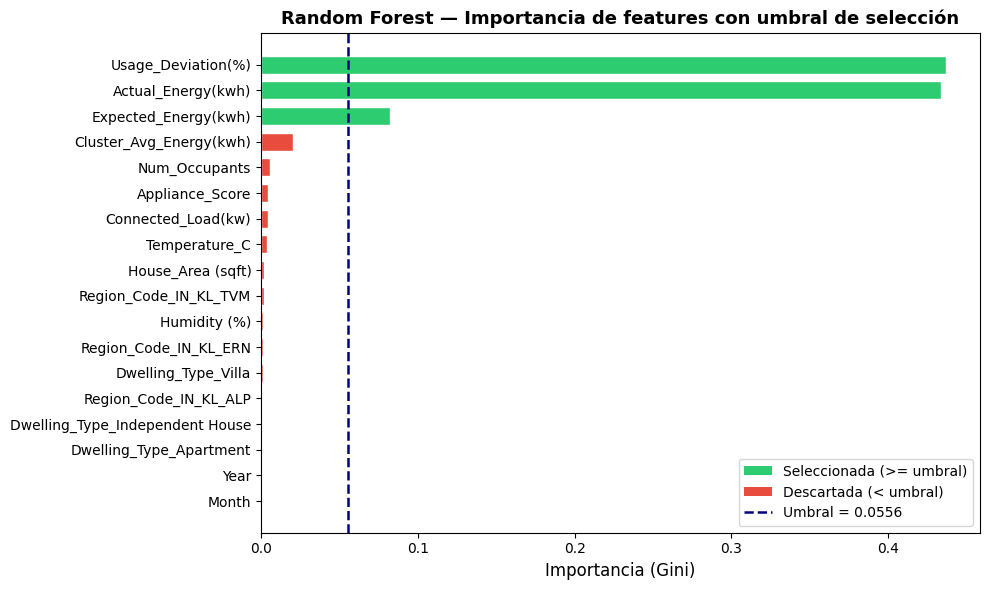

In [71]:
#Grafico
feature_imp_rf_df=pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=True)

colores_rf=['#2ecc71' if imp >= umbral_rf else '#e74c3c'
              for imp in feature_imp_rf_df['importance']]

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_rf_df['feature'], feature_imp_rf_df['importance'],
         color=colores_rf, edgecolor='white', height=0.7)
plt.axvline(x=umbral_rf, color='navy', linestyle='--', linewidth=1.8,
            label=f'Umbral (mean = {umbral_rf:.4f})')
plt.xlabel('Importancia (Gini)', fontsize=12)
plt.title('Random Forest — Importancia de features con umbral de selección',
          fontsize=13, fontweight='bold')

#from matplotlib.patches import Patch
legend_elements=[
    Patch(facecolor='#2ecc71', label='Seleccionada (>= umbral)'),
    Patch(facecolor='#e74c3c', label='Descartada (< umbral)'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               linewidth=1.8, label=f'Umbral = {umbral_rf:.4f}')
]
plt.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

In [72]:
#Reentrenar RF con los hiperparámetros y features seleccionadas
rf_fs=RandomForestClassifier(
    **random_search_rf.best_params_,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_fs.fit(X_train_rf_fs, y_train)

y_pred_rf_fs=rf_fs.predict(X_test_rf_fs)
y_pred_proba_rf_fs=rf_fs.predict_proba(X_test_rf_fs)[:, 1]

print("ResultadoS (CON IMPORTANCIA GINI))")
print(f"Features usadas: {len(features_seleccionadas_rf)} de {X.shape[1]}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_fs):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_fs):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_fs):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_fs):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf_fs):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf_fs, target_names=['Normal', 'Anómalo']))

ResultadoS (CON IMPORTANCIA GINI))
Features usadas: 3 de 18
Accuracy: 0.9755
Precision: 0.9725
Recall: 0.9715
F1-Score: 0.9720
ROC-AUC: 0.9975

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1212
     Anómalo       0.97      0.97      0.97       948

    accuracy                           0.98      2160
   macro avg       0.98      0.98      0.98      2160
weighted avg       0.98      0.98      0.98      2160



In [73]:
#Datos de RF completo y con selección
comparacion_rf_fs=pd.DataFrame({
    'Modelo'      : ['RF Optimizado (todas las features)',
                     f'RF + Importancia Gini ({len(features_seleccionadas_rf)} features, umbral=mean)'],
    'N° Features' : [X.shape[1], len(features_seleccionadas_rf)],
    'Accuracy'    : [accuracy_score(y_test, y_pred_rf_best),  accuracy_score(y_test, y_pred_rf_fs)],
    'Precision'   : [precision_score(y_test, y_pred_rf_best), precision_score(y_test, y_pred_rf_fs)],
    'Recall'      : [recall_score(y_test, y_pred_rf_best),    recall_score(y_test, y_pred_rf_fs)],
    'F1-Score'    : [f1_score(y_test, y_pred_rf_best),        f1_score(y_test, y_pred_rf_fs)],
    'ROC-AUC'     : [roc_auc_score(y_test, y_pred_proba_rf_best), roc_auc_score(y_test, y_pred_proba_rf_fs)]
})

print("Comparación RF —  TODAS las features vs. SELECCIÓN (gini)):")
print(comparacion_rf_fs.round(4).to_string(index=False))

Comparación RF —  TODAS las features vs. SELECCIÓN (gini)):
                                         Modelo  N° Features  Accuracy  Precision  Recall  F1-Score  ROC-AUC
             RF Optimizado (todas las features)           18    0.9935     0.9916  0.9937    0.9926   0.9994
RF + Importancia Gini (3 features, umbral=mean)            3    0.9755     0.9725  0.9715    0.9720   0.9975


### 13.2 Validación cruzada — Todas las características

In [74]:
t0=time.time()

cv_results_rf_completo=cross_validate(rf_best,
                                        X_train, y_train,
                                        cv=cv_5fold,
                                        scoring=scoring_metrics,
                                        n_jobs=-1,
                                        return_train_score=True    #Detectar overfitting comparando train vs validación
)

print("\nResultados: Validación cruzada:) (Todas las features)")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores=cv_results_rf_completo[f'test_{metrica}']
    train_scores=cv_results_rf_completo[f'train_{metrica}']
    print(f" {metrica:10s} | Val: {val_scores.mean():.4f} +- {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} +- {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


Resultados: Validación cruzada:) (Todas las features)
 accuracy   | Val: 0.9944 +- 0.0014 | Train: 0.9989 +- 0.0002
 precision  | Val: 0.9921 +- 0.0048 | Train: 0.9981 +- 0.0005
 recall     | Val: 0.9953 +- 0.0018 | Train: 0.9995 +- 0.0002
 f1         | Val: 0.9937 +- 0.0016 | Train: 0.9988 +- 0.0002
 roc_auc    | Val: 0.9998 +- 0.0000 | Train: 1.0000 +- 0.0000

Tiempo: 2.1s


### Validación cruzada — Selección por importancia

In [75]:
t0=time.time()
#(umbral = mean)
cv_results_rf_fs = cross_validate(rf_fs,
                                  X_train_rf_fs, y_train,
                                  cv=cv_5fold,
                                  scoring=scoring_metrics,
                                  n_jobs=-1,
                                  return_train_score=True
)

print("\nResultados: Validación cruzada (Selección por importancia)")
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    val_scores=cv_results_rf_fs[f'test_{metrica}']
    train_scores=cv_results_rf_fs[f'train_{metrica}']
    print(f" {metrica:10s} | Val: {val_scores.mean():.4f} +- {val_scores.std():.4f} "
          f"| Train: {train_scores.mean():.4f} +- {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


Resultados: Validación cruzada (Selección por importancia)
 accuracy   | Val: 0.9759 +- 0.0022 | Train: 0.9911 +- 0.0006
 precision  | Val: 0.9731 +- 0.0067 | Train: 0.9917 +- 0.0011
 recall     | Val: 0.9720 +- 0.0052 | Train: 0.9879 +- 0.0020
 f1         | Val: 0.9726 +- 0.0025 | Train: 0.9898 +- 0.0007
 roc_auc    | Val: 0.9975 +- 0.0007 | Train: 0.9998 +- 0.0000

Tiempo: 1.5s


### 13.4 Comparaciones de validación cruzada

In [76]:
metricas_cv=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resumen_cv_rf=pd.DataFrame({
    'Métrica'           : metricas_cv,
    'RF_Completo_Media' : [cv_results_rf_completo[f'test_{m}'].mean() for m in metricas_cv],
    'RF_Completo_Std'   : [cv_results_rf_completo[f'test_{m}'].std()  for m in metricas_cv],
    'RF_FS_Media'       : [cv_results_rf_fs[f'test_{m}'].mean()       for m in metricas_cv],
    'RF_FS_Std'         : [cv_results_rf_fs[f'test_{m}'].std()        for m in metricas_cv],
})

print("Comparación: RF Completo vs. RF Selección de Importancia")
print(resumen_cv_rf.round(4).to_string(index=False))

Comparación: RF Completo vs. RF Selección de Importancia
  Métrica  RF_Completo_Media  RF_Completo_Std  RF_FS_Media  RF_FS_Std
 accuracy             0.9944           0.0014       0.9759     0.0022
precision             0.9921           0.0048       0.9731     0.0067
   recall             0.9953           0.0018       0.9720     0.0052
       f1             0.9937           0.0016       0.9726     0.0025
  roc_auc             0.9998           0.0000       0.9975     0.0007


## 14. Comparación final con Validación Cruzada

Se comparan los 4 modelos en:
1. Métricas en test set: modelos completos vs modelos con selección de variables
2. Validación cruzada (5-fold): media y desviación estándar para evaluar estabilidad
3. Curvas ROC: modelos completos vs modelos con selección de variables

### 14.1 Comparación de metricas test set

In [77]:
metricas=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

comparison_fs_df=pd.DataFrame({
    'Modelo': [
        'SVM Optimizado',      'SVM + Selección',
        'XGBoost Optimizado',  'XGBoost + Selección',
        'KNN Optimizado',      'KNN + Selección',
        'RF Optimizado',       'RF + Selección',
    ],
    'N° Features': [
        n_features_total, len(features_seleccionadas_svm),
        n_features_total, len(features_seleccionadas_xgb),
        n_features_total, len(features_seleccionadas_knn_opt),
        n_features_total, len(features_seleccionadas_rf),
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm_best),  accuracy_score(y_test, y_pred_svm_fs),
        accuracy_score(y_test, y_pred_xgb_best),  accuracy_score(y_test, y_pred_xgb_fs),
        accuracy_score(y_test, y_pred_knn_best),  accuracy_score(y_test, y_pred_knn_fs),
        accuracy_score(y_test, y_pred_rf_best),   accuracy_score(y_test, y_pred_rf_fs),
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm_best),  precision_score(y_test, y_pred_svm_fs),
        precision_score(y_test, y_pred_xgb_best),  precision_score(y_test, y_pred_xgb_fs),
        precision_score(y_test, y_pred_knn_best),  precision_score(y_test, y_pred_knn_fs),
        precision_score(y_test, y_pred_rf_best),   precision_score(y_test, y_pred_rf_fs),
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm_best),  recall_score(y_test, y_pred_svm_fs),
        recall_score(y_test, y_pred_xgb_best),  recall_score(y_test, y_pred_xgb_fs),
        recall_score(y_test, y_pred_knn_best),  recall_score(y_test, y_pred_knn_fs),
        recall_score(y_test, y_pred_rf_best),   recall_score(y_test, y_pred_rf_fs),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm_best),  f1_score(y_test, y_pred_svm_fs),
        f1_score(y_test, y_pred_xgb_best),  f1_score(y_test, y_pred_xgb_fs),
        f1_score(y_test, y_pred_knn_best),  f1_score(y_test, y_pred_knn_fs),
        f1_score(y_test, y_pred_rf_best),   f1_score(y_test, y_pred_rf_fs),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_svm_best),  roc_auc_score(y_test, y_pred_proba_svm_fs),
        roc_auc_score(y_test, y_pred_proba_xgb_best),  roc_auc_score(y_test, y_pred_proba_xgb_fs),
        roc_auc_score(y_test, y_pred_proba_knn_best),  roc_auc_score(y_test, y_pred_proba_knn_fs),
        roc_auc_score(y_test, y_pred_proba_rf_best),   roc_auc_score(y_test, y_pred_proba_rf_fs),
    ],
})

print("COMPARACIÓN : Modelos completos vs Modelos con selección de variables")
print(comparison_fs_df.round(4).to_string(index=False))
# Mejor modelo con selección
solo_sel = comparison_fs_df[comparison_fs_df['Modelo'].str.contains('Selección')]
best_fs_idx = solo_sel['F1-Score'].idxmax()
print(f"\nMejor modelo con selección: {comparison_fs_df.loc[best_fs_idx, 'Modelo']}")
print(f"  F1-Score : {comparison_fs_df.loc[best_fs_idx, 'F1-Score']:.4f}")
print(f"  ROC-AUC  : {comparison_fs_df.loc[best_fs_idx, 'ROC-AUC']:.4f}")
print(f"  Features : {comparison_fs_df.loc[best_fs_idx, 'N° Features']} de {n_features_total}")

COMPARACIÓN : Modelos completos vs Modelos con selección de variables
             Modelo  N° Features  Accuracy  Precision  Recall  F1-Score  ROC-AUC
     SVM Optimizado           18    0.9255     0.9816  0.8460    0.9088   0.9670
    SVM + Selección            4    0.9537     0.9930  0.9008    0.9447   0.9821
 XGBoost Optimizado           18    0.9907     0.9895  0.9895    0.9895   0.9990
XGBoost + Selección            2    0.9718     0.9733  0.9620    0.9676   0.9966
     KNN Optimizado           18    0.8593     0.9653  0.7046    0.8146   0.9145
    KNN + Selección            2    0.9579     0.9413  0.9641    0.9526   0.9896
      RF Optimizado           18    0.9935     0.9916  0.9937    0.9926   0.9994
     RF + Selección            3    0.9755     0.9725  0.9715    0.9720   0.9975

Mejor modelo con selección: RF + Selección
  F1-Score : 0.9720
  ROC-AUC  : 0.9975
  Features : 3 de 18


### 14.2 Selección de variables

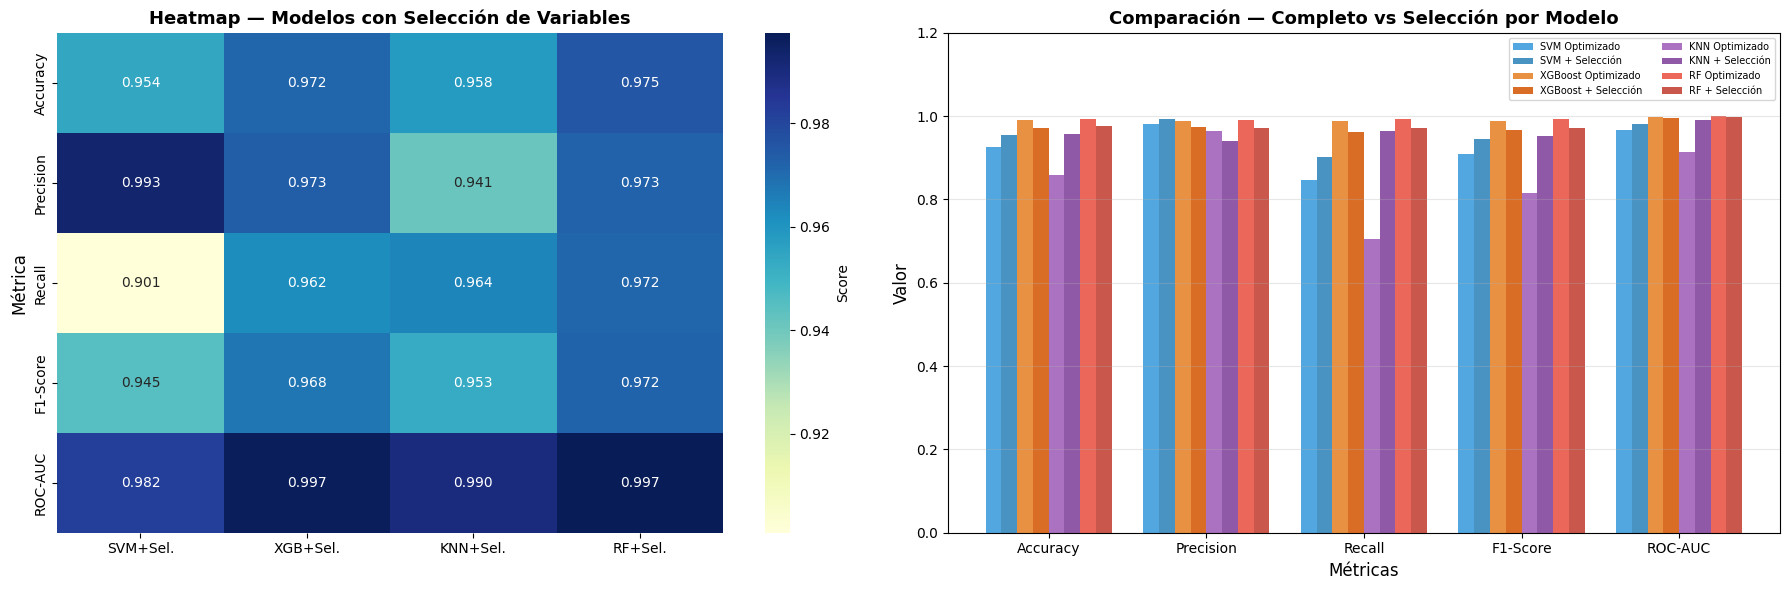

In [78]:
seleccion_var=comparison_fs_df[comparison_fs_df['Modelo'].str.contains('Selección')]

fig, axes=plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(
    seleccion_var[metricas].T.astype(float),
    annot=True, fmt='.3f', cmap='YlGnBu',
    cbar_kws={'label': 'Score'}, ax=axes[0],
    xticklabels=['SVM+Sel.', 'XGB+Sel.', 'KNN+Sel.', 'RF+Sel.']
)
axes[0].set_title('Heatmap — Modelos con Selección de Variables',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Métrica', fontsize=12)

# Grafico Barras
x=np.arange(len(metricas))
width=0.10
colors=['#3498db', '#2980b9', '#e67e22', '#d35400',
          '#9b59b6', '#7d3c98', '#e74c3c', '#c0392b']

for i, (_, row) in enumerate(comparison_fs_df.iterrows()):
    axes[1].bar(x + i*width, row[metricas].values, width,
                label=row['Modelo'], alpha=0.85, color=colors[i])

axes[1].set_xlabel('Métricas', fontsize=12)
axes[1].set_ylabel('Valor', fontsize=12)
axes[1].set_title('Comparación — Completo vs Selección por Modelo',
                  fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width * 3.5)
axes[1].set_xticklabels(metricas)
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.2])

plt.tight_layout()
plt.show()

### 14.3 Validación cruzada

In [79]:
metricas_vc=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

#Modelos completos
vc_completo = pd.DataFrame({
    'Métrica'   : metricas_vc,
    'SVM_Media' : [cv_results_svm_completo[f'test_{m}'].mean() for m in metricas_cv],
    'SVM_Std'   : [cv_results_svm_completo[f'test_{m}'].std()  for m in metricas_cv],
    'XGB_Media' : [cv_results_xgb_completo[f'test_{m}'].mean() for m in metricas_cv],
    'XGB_Std'   : [cv_results_xgb_completo[f'test_{m}'].std()  for m in metricas_cv],
    'KNN_Media' : [cv_results_knn_completo[f'test_{m}'].mean() for m in metricas_cv],
    'KNN_Std'   : [cv_results_knn_completo[f'test_{m}'].std()  for m in metricas_cv],
    'RF_Media'  : [cv_results_rf_completo[f'test_{m}'].mean()  for m in metricas_cv],
    'RF_Std'    : [cv_results_rf_completo[f'test_{m}'].std()   for m in metricas_cv],
})

print("Validación Cruzada (5-fold) — Completos")
print(vc_completo.round(4).to_string(index=False))

# Modelos con selección
vc_seleccion = pd.DataFrame({
    'Métrica'      : metricas_vc,
    'SVM_FS_Media' : [cv_results_svm_fs[f'test_{m}'].mean() for m in metricas_cv],
    'SVM_FS_Std'   : [cv_results_svm_fs[f'test_{m}'].std()  for m in metricas_cv],
    'XGB_FS_Media' : [cv_results_xgb_fs[f'test_{m}'].mean() for m in metricas_cv],
    'XGB_FS_Std'   : [cv_results_xgb_fs[f'test_{m}'].std()  for m in metricas_cv],
    'KNN_FS_Media' : [cv_results_knn_fs[f'test_{m}'].mean() for m in metricas_cv],
    'KNN_FS_Std'   : [cv_results_knn_fs[f'test_{m}'].std()  for m in metricas_cv],
    'RF_FS_Media'  : [cv_results_rf_fs[f'test_{m}'].mean()  for m in metricas_cv],
    'RF_FS_Std'    : [cv_results_rf_fs[f'test_{m}'].std()   for m in metricas_cv],
})

print("\nValidación Cruzada (5-fold) — Con selección de variables")
print(vc_seleccion.round(4).to_string(index=False))

Validación Cruzada (5-fold) — Completos
  Métrica  SVM_Media  SVM_Std  XGB_Media  XGB_Std  KNN_Media  KNN_Std  RF_Media  RF_Std
 accuracy     0.9271   0.0054     0.9933   0.0022     0.8703   0.0093    0.9944  0.0014
precision     0.9792   0.0048     0.9898   0.0051     0.9596   0.0069    0.9921  0.0048
   recall     0.8520   0.0156     0.9950   0.0027     0.7352   0.0172    0.9953  0.0018
       f1     0.9111   0.0074     0.9924   0.0025     0.8325   0.0133    0.9937  0.0016
  roc_auc     0.9636   0.0069     0.9996   0.0003     0.9258   0.0143    0.9998  0.0000

Validación Cruzada (5-fold) — Con selección de variables
  Métrica  SVM_FS_Media  SVM_FS_Std  XGB_FS_Media  XGB_FS_Std  KNN_FS_Media  KNN_FS_Std  RF_FS_Media  RF_FS_Std
 accuracy        0.9591      0.0059        0.9740      0.0025        0.9609      0.0027       0.9759     0.0022
precision        0.9929      0.0026        0.9722      0.0053        0.9477      0.0072       0.9731     0.0067
   recall        0.9135      0.0149   

### 14.4 Gráficos de Validación Cruzada: F1-Score y ROC-AUC

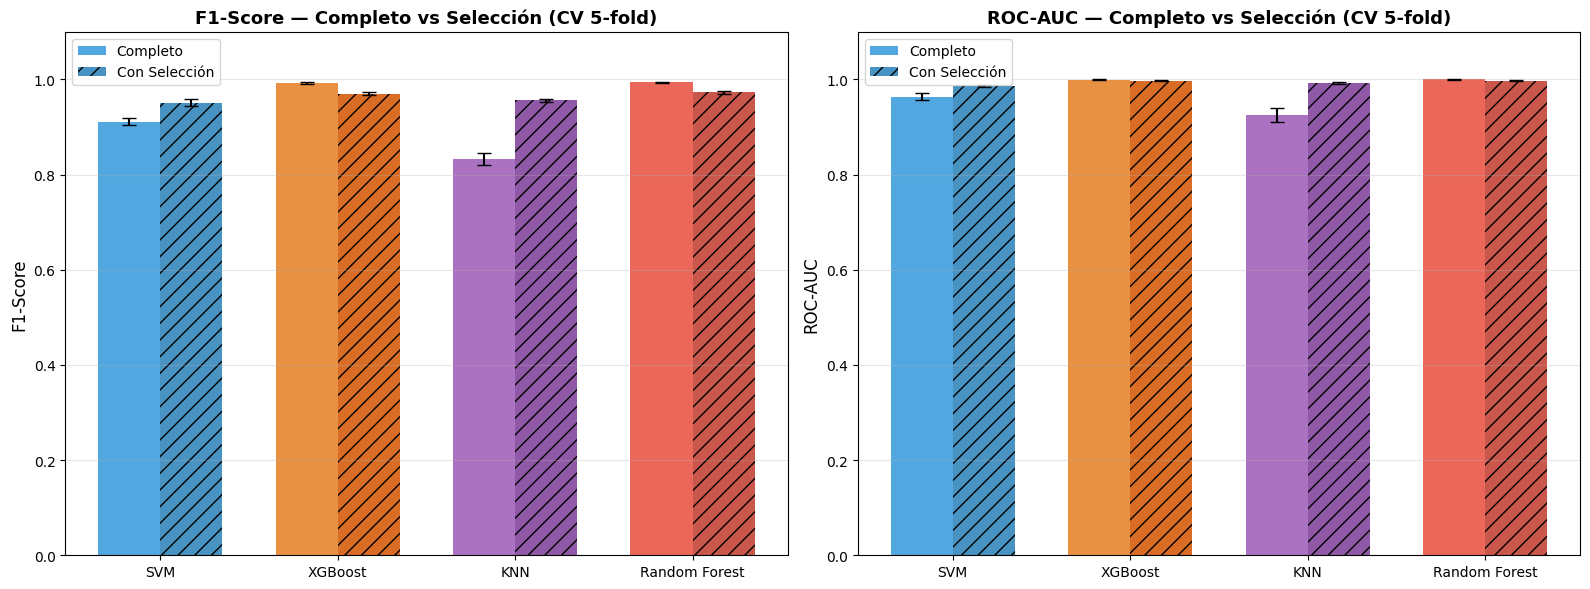

In [80]:
modelos=['SVM', 'XGBoost', 'KNN', 'Random Forest']
colores_comp=['#3498db', '#e67e22', '#9b59b6', '#e74c3c']
colores_fs=['#2980b9', '#d35400', '#7d3c98', '#c0392b']

f1_comp_mean = [cv_results_svm_completo['test_f1'].mean(),
                cv_results_xgb_completo['test_f1'].mean(),
                cv_results_knn_completo['test_f1'].mean(),
                cv_results_rf_completo['test_f1'].mean()]
f1_comp_std  = [cv_results_svm_completo['test_f1'].std(),
                cv_results_xgb_completo['test_f1'].std(),
                cv_results_knn_completo['test_f1'].std(),
                cv_results_rf_completo['test_f1'].std()]
f1_fs_mean   = [cv_results_svm_fs['test_f1'].mean(),
                cv_results_xgb_fs['test_f1'].mean(),
                cv_results_knn_fs['test_f1'].mean(),
                cv_results_rf_fs['test_f1'].mean()]
f1_fs_std    = [cv_results_svm_fs['test_f1'].std(),
                cv_results_xgb_fs['test_f1'].std(),
                cv_results_knn_fs['test_f1'].std(),
                cv_results_rf_fs['test_f1'].std()]

auc_comp_mean = [cv_results_svm_completo['test_roc_auc'].mean(),
                 cv_results_xgb_completo['test_roc_auc'].mean(),
                 cv_results_knn_completo['test_roc_auc'].mean(),
                 cv_results_rf_completo['test_roc_auc'].mean()]
auc_comp_std  = [cv_results_svm_completo['test_roc_auc'].std(),
                 cv_results_xgb_completo['test_roc_auc'].std(),
                 cv_results_knn_completo['test_roc_auc'].std(),
                 cv_results_rf_completo['test_roc_auc'].std()]
auc_fs_mean   = [cv_results_svm_fs['test_roc_auc'].mean(),
                 cv_results_xgb_fs['test_roc_auc'].mean(),
                 cv_results_knn_fs['test_roc_auc'].mean(),
                 cv_results_rf_fs['test_roc_auc'].mean()]
auc_fs_std    = [cv_results_svm_fs['test_roc_auc'].std(),
                 cv_results_xgb_fs['test_roc_auc'].std(),
                 cv_results_knn_fs['test_roc_auc'].std(),
                 cv_results_rf_fs['test_roc_auc'].std()]

x=np.arange(len(modelos))
width=0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-Score
axes[0].bar(x - width/2, f1_comp_mean, width, yerr=f1_comp_std,
            label='Completo', color=colores_comp, alpha=0.85,
            capsize=5, error_kw={'linewidth': 1.5})
axes[0].bar(x + width/2, f1_fs_mean, width, yerr=f1_fs_std,
            label='Con Selección', color=colores_fs, alpha=0.85,
            capsize=5, error_kw={'linewidth': 1.5}, hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_title('F1-Score — Completo vs Selección (CV 5-fold)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# ROC-AUC
axes[1].bar(x - width/2, auc_comp_mean, width, yerr=auc_comp_std,
            label='Completo', color=colores_comp, alpha=0.85,
            capsize=5, error_kw={'linewidth': 1.5})
axes[1].bar(x + width/2, auc_fs_mean, width, yerr=auc_fs_std,
            label='Con Selección', color=colores_fs, alpha=0.85,
            capsize=5, error_kw={'linewidth': 1.5}, hatch='//')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_title('ROC-AUC — Completo vs Selección (CV 5-fold)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

### 14.5 Curvas ROC

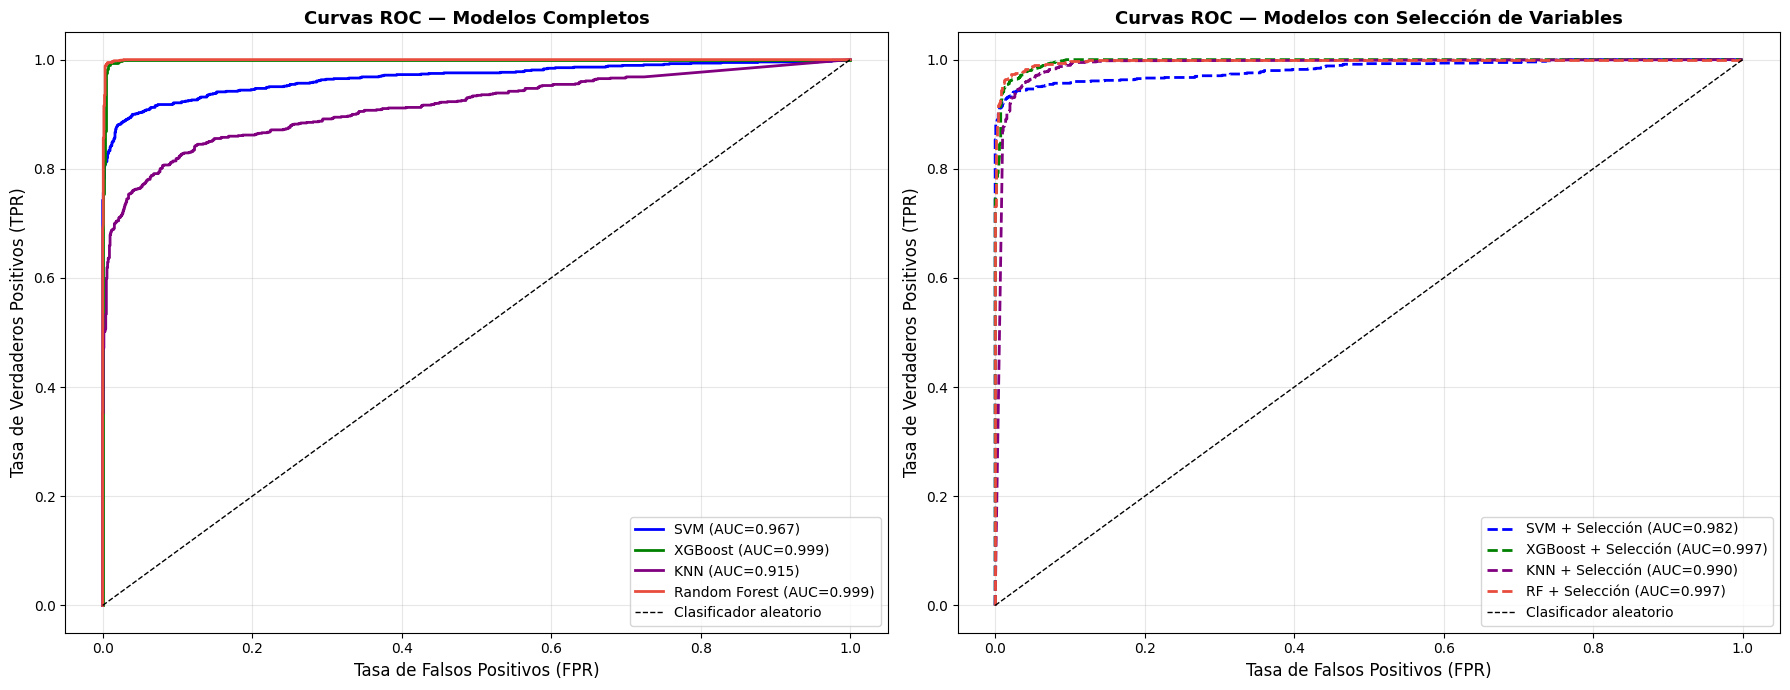

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Curvas ROC — modelos completos
for proba, color, label in [
    (y_pred_proba_svm_best, 'blue',    'SVM'),
    (y_pred_proba_xgb_best, 'green',   'XGBoost'),
    (y_pred_proba_knn_best, 'purple',  'KNN'),
    (y_pred_proba_rf_best,  '#e74c3c', 'Random Forest'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', linewidth=2, color=color)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Clasificador aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[0].set_title('Curvas ROC — Modelos Completos', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Curvas ROC — modelos con selección
for proba, color, label in [
    (y_pred_proba_svm_fs,  'blue',    'SVM + Selección'),
    (y_pred_proba_xgb_fs,  'green',   'XGBoost + Selección'),
    (y_pred_proba_knn_fs,  'purple',  'KNN + Selección'),
    (y_pred_proba_rf_fs,   '#e74c3c', 'RF + Selección'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', linewidth=2,
                 color=color, linestyle='--')

axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[1].set_title('Curvas ROC — Modelos con Selección de Variables',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Ensamble de Modelos (con Selección de Features)

Se combinan los 4 modelos con sus features seleccionadas (SVM, XGBoost, KNN, Random Forest) usando dos estrategias de votación:

- **Hard Voting**: cada modelo vota su clase predicha (0 o 1); gana la mayoría.
- **Soft Voting**: cada modelo aporta probabilidades; se promedian y gana la clase con mayor probabilidad promedio.

Dado que cada modelo fue entrenado con un subconjunto **distinto** de features, se usa un `Pipeline` para cada uno.
El Pipeline aplica primero la selección de features propia de ese modelo y luego hace la predicción.
Así el `VotingClassifier` puede recibir las 14 features originales y cada modelo internamente toma solo las que necesita.

### 15.1 Construcción de los Pipelines

Cada Pipeline tiene dos pasos:
1. elector: filtra las columnas que corresponden a ese modelo.
2. Modelo: el clasificador entrenado con esas features.

- SVM y KNN: usan `FunctionTransformer` con una lista de features seleccionadas (no tienen objeto transformador guardado).
- XGBoost y RF: usan directamente `selector_xgb` y `selector_rf` (objetos `SelectFromModel` ya ajustados).

Nota sobre datos de entrada: se usa `X_train_scaled` / `X_test_scaled` para todos.
XGBoost y RF no se ven afectados por el escalado porque trabajan con árboles de decisión.

In [82]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Selectores para SVM y KNN (basados en listas de features)
# FunctionTransformer convierte la lista de features en un transformador
# compatible con Pipeline. Recibe un DataFrame y devuelve solo las columnas
# seleccionadas.

def make_column_selector(feature_list):
    """Crea un transformador que filtra columnas por nombre."""
    return FunctionTransformer(
        lambda X: X[feature_list] if hasattr(X, '__getitem__') else X[:, [list(X.columns).index(f) for f in feature_list]],
        feature_names_out='one-to-one'
    )

# Pipeline SVM: filtra features_seleccionadas_svm -> predice con svm_fs
pipe_svm = Pipeline([
    ('selector', FunctionTransformer(lambda X: X[features_seleccionadas_svm])),
    ('modelo',   svm_fs)
])

# Pipeline XGBoost: selector_xgb ya es un transformador ajustado
# Necesita array numpy, no DataFrame -> se convierte con .values internamente
pipe_xgb = Pipeline([
    ('selector', FunctionTransformer(lambda X: selector_xgb.transform(X))),
    ('modelo',   xgb_fs)
])

# Pipeline KNN: filtra features_seleccionadas_knn_opt -> predice con knn_fs
pipe_knn = Pipeline([
    ('selector', FunctionTransformer(lambda X: X[features_seleccionadas_knn_opt])),
    ('modelo',   knn_fs)
])

# Pipeline RF: selector_rf ya es un transformador ajustado
pipe_rf = Pipeline([
    ('selector', FunctionTransformer(lambda X: selector_rf.transform(X))),
    ('modelo',   rf_fs)
])

print("Pipelines construidos:")
print(f"  pipe_svm -> features: {list(features_seleccionadas_svm)}")
print(f"  pipe_xgb -> features: {list(features_seleccionadas_xgb)}")
print(f"  pipe_knn -> features: {list(features_seleccionadas_knn_opt)}")
print(f"  pipe_rf  -> features: {list(features_seleccionadas_rf)}")

Pipelines construidos:
  pipe_svm -> features: ['Usage_Deviation(%)', 'Actual_Energy(kwh)', 'Expected_Energy(kwh)', 'Cluster_Avg_Energy(kwh)']
  pipe_xgb -> features: ['Actual_Energy(kwh)', 'Usage_Deviation(%)']
  pipe_knn -> features: ['Actual_Energy(kwh)', 'Usage_Deviation(%)']
  pipe_rf  -> features: ['Expected_Energy(kwh)', 'Actual_Energy(kwh)', 'Usage_Deviation(%)']


In [83]:
# Hard Voting
ensemble_hard_fs = VotingClassifier(
    estimators = [
        ('svm', pipe_svm),
        ('xgb', pipe_xgb),
        ('knn', pipe_knn),
        ('rf',  pipe_rf),
    ],
    voting = 'hard'
)
ensemble_hard_fs.fit(X_train_scaled, y_train)
print("Ensamble Hard Voting (con selección de features) entrenado")

# Soft Voting
ensemble_soft_fs = VotingClassifier(
    estimators = [
        ('svm', pipe_svm),
        ('xgb', pipe_xgb),
        ('knn', pipe_knn),
        ('rf',  pipe_rf),
    ],
    voting = 'soft'
)
ensemble_soft_fs.fit(X_train_scaled, y_train)
print("Ensamble Soft Voting (con selección de features) entrenado")

Ensamble Hard Voting (con selección de features) entrenado
Ensamble Soft Voting (con selección de features) entrenado


### 15.2 Evaluación de los ensambles

In [84]:
# Predicciones
y_pred_hard_fs       = ensemble_hard_fs.predict(X_test_scaled)
y_pred_soft_fs       = ensemble_soft_fs.predict(X_test_scaled)
y_pred_proba_soft_fs = ensemble_soft_fs.predict_proba(X_test_scaled)[:, 1]

# Resultados Hard Voting
print("RESULTADOS ENSAMBLE FS — HARD VOTING")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_hard_fs):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_hard_fs):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_hard_fs):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_hard_fs):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_hard_fs, target_names=['Normal', 'Anómalo']))

# Resultados Soft Voting
print("RESULTADOS ENSAMBLE FS — SOFT VOTING")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_soft_fs):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_soft_fs):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_soft_fs):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_soft_fs):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba_soft_fs):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_soft_fs, target_names=['Normal', 'Anómalo']))

RESULTADOS ENSAMBLE FS — HARD VOTING
  Accuracy  : 0.9736
  Precision : 0.9785
  Recall    : 0.9610
  F1-Score  : 0.9697

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      1212
     Anómalo       0.98      0.96      0.97       948

    accuracy                           0.97      2160
   macro avg       0.97      0.97      0.97      2160
weighted avg       0.97      0.97      0.97      2160

RESULTADOS ENSAMBLE FS — SOFT VOTING
  Accuracy  : 0.9778
  Precision : 0.9767
  Recall    : 0.9726
  F1-Score  : 0.9746
  ROC-AUC   : 0.9984

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1212
     Anómalo       0.98      0.97      0.97       948

    accuracy                           0.98      2160
   macro avg       0.98      0.98      0.98      2160
weighted avg       0.98      0.98      0.98      2160



### 15.3 Matrices de confusión — Hard Voting vs Soft Voting

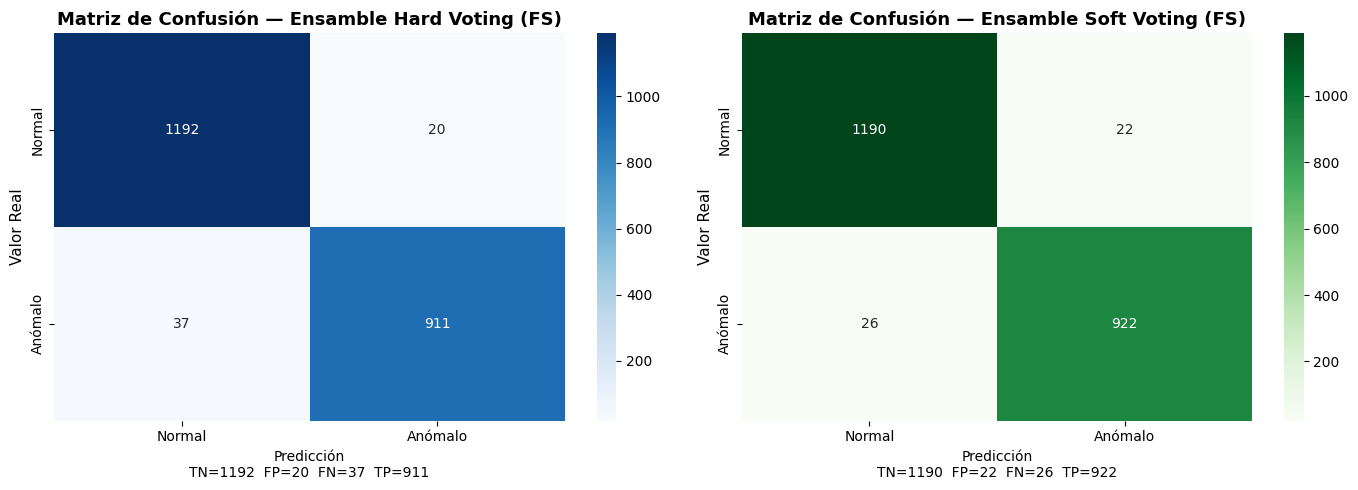

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo, cmap in [
    (axes[0], y_pred_hard_fs, 'Hard Voting (FS)', 'Blues'),
    (axes[1], y_pred_soft_fs, 'Soft Voting (FS)', 'Greens'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
                xticklabels=['Normal', 'Anómalo'],
                yticklabels=['Normal', 'Anómalo'], ax=ax)
    ax.set_title(f'Matriz de Confusión — Ensamble {titulo}',
                 fontsize=13, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicción\nTN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=10)
    ax.set_ylabel('Valor Real', fontsize=11)

plt.tight_layout()
plt.show()

### 15.4 Comparación: ensambles vs modelos con selección de features

In [86]:
# Tabla comparativa: modelos _fs individuales + ensambles con FS
resumen_ensamble_fs = pd.DataFrame({
    'Modelo'   : [
        'SVM + FS', 'XGBoost + FS', 'KNN + FS', 'RF + FS',
        'Ensamble Hard Voting (FS)', 'Ensamble Soft Voting (FS)'
    ],
    'Accuracy' : [
        accuracy_score(y_test, y_pred_svm_fs),
        accuracy_score(y_test, y_pred_xgb_fs),
        accuracy_score(y_test, y_pred_knn_fs),
        accuracy_score(y_test, y_pred_rf_fs),
        accuracy_score(y_test, y_pred_hard_fs),
        accuracy_score(y_test, y_pred_soft_fs),
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm_fs),
        precision_score(y_test, y_pred_xgb_fs),
        precision_score(y_test, y_pred_knn_fs),
        precision_score(y_test, y_pred_rf_fs),
        precision_score(y_test, y_pred_hard_fs),
        precision_score(y_test, y_pred_soft_fs),
    ],
    'Recall'   : [
        recall_score(y_test, y_pred_svm_fs),
        recall_score(y_test, y_pred_xgb_fs),
        recall_score(y_test, y_pred_knn_fs),
        recall_score(y_test, y_pred_rf_fs),
        recall_score(y_test, y_pred_hard_fs),
        recall_score(y_test, y_pred_soft_fs),
    ],
    'F1-Score' : [
        f1_score(y_test, y_pred_svm_fs),
        f1_score(y_test, y_pred_xgb_fs),
        f1_score(y_test, y_pred_knn_fs),
        f1_score(y_test, y_pred_rf_fs),
        f1_score(y_test, y_pred_hard_fs),
        f1_score(y_test, y_pred_soft_fs),
    ],
    'ROC-AUC'  : [
        roc_auc_score(y_test, y_pred_proba_svm_fs),
        roc_auc_score(y_test, y_pred_proba_xgb_fs),
        roc_auc_score(y_test, y_pred_proba_knn_fs),
        roc_auc_score(y_test, y_pred_proba_rf_fs),
        float('nan'),                                  # Hard voting no tiene predict_proba
        roc_auc_score(y_test, y_pred_proba_soft_fs),
    ],
})

print("COMPARACIÓN: Modelos con selección de features vs Ensambles (FS)")
print(resumen_ensamble_fs.round(4).to_string(index=False))

COMPARACIÓN: Modelos con selección de features vs Ensambles (FS)
                   Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
                 SVM + FS    0.9537     0.9930  0.9008    0.9447   0.9821
             XGBoost + FS    0.9718     0.9733  0.9620    0.9676   0.9966
                 KNN + FS    0.9579     0.9413  0.9641    0.9526   0.9896
                  RF + FS    0.9755     0.9725  0.9715    0.9720   0.9975
Ensamble Hard Voting (FS)    0.9736     0.9785  0.9610    0.9697      NaN
Ensamble Soft Voting (FS)    0.9778     0.9767  0.9726    0.9746   0.9984


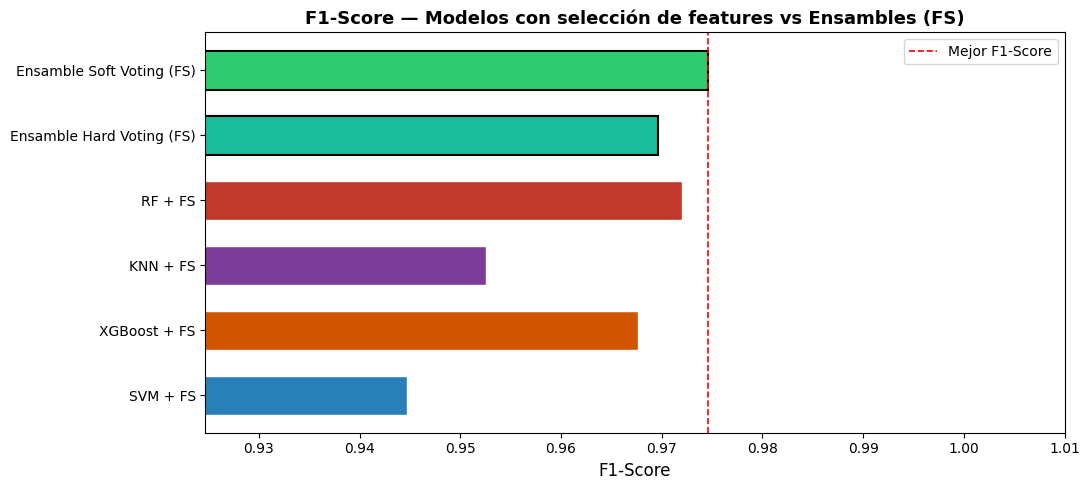

In [87]:
# Gráfica de F1-Score
colores = ['#2980b9', '#d35400', '#7d3c98', '#c0392b', '#1abc9c', '#2ecc71']

plt.figure(figsize=(11, 5))
bars = plt.barh(resumen_ensamble_fs['Modelo'], resumen_ensamble_fs['F1-Score'],
                color=colores, edgecolor='white', height=0.6)

for i, bar in enumerate(bars):
    if i >= 4:
        bar.set_edgecolor('black')
        bar.set_linewidth(1.5)

plt.axvline(x=resumen_ensamble_fs['F1-Score'].max(), color='red',
            linestyle='--', linewidth=1.2, label='Mejor F1-Score')
plt.xlabel('F1-Score', fontsize=12)
plt.title('F1-Score — Modelos con selección de features vs Ensambles (FS)',
          fontsize=13, fontweight='bold')
plt.xlim(resumen_ensamble_fs['F1-Score'].min() - 0.02, 1.01)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 15.5 Curva ROC — Soft Voting (FS) vs modelos con selección de features

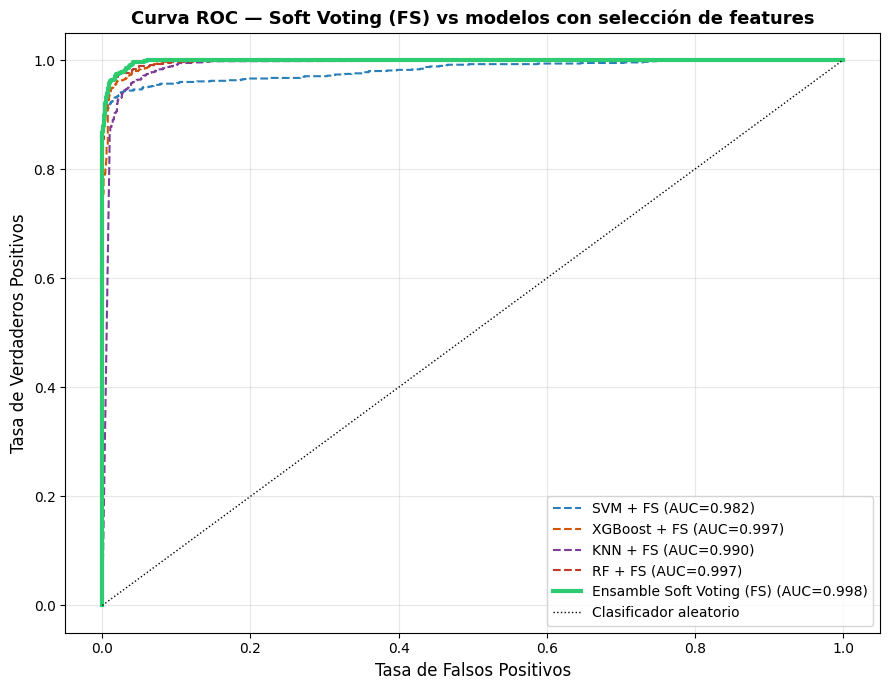

In [88]:
plt.figure(figsize=(9, 7))

for proba, color, label in [
    (y_pred_proba_svm_fs,   '#2980b9',  'SVM + FS'),
    (y_pred_proba_xgb_fs,   '#d35400',  'XGBoost + FS'),
    (y_pred_proba_knn_fs,   '#7d3c98',  'KNN + FS'),
    (y_pred_proba_rf_fs,    '#c0392b',  'RF + FS'),
    (y_pred_proba_soft_fs,  '#2ecc71',  'Ensamble Soft Voting (FS)'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    lw  = 3   if 'Ensamble' in label else 1.5
    ls  = '-'  if 'Ensamble' in label else '--'
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})',
             linewidth=lw, linestyle=ls, color=color)

plt.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Curva ROC — Soft Voting (FS) vs modelos con selección de features',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Ensamble de Modelos (con Selección de Features)

Se combinan 3 modelos con sus features seleccionadas (SVM, XGBoost, KNN) usando dos estrategias de votación:

- **Hard Voting**: cada modelo vota su clase predicha (0 o 1); gana la mayoría.
- **Soft Voting**: cada modelo aporta probabilidades; se promedian y gana la clase con mayor probabilidad promedio.

Dado que cada modelo fue entrenado con un subconjunto **distinto** de features, se usa un `Pipeline` para cada uno.
El Pipeline aplica primero la selección de features propia de ese modelo y luego hace la predicción.
Así el `VotingClassifier` puede recibir las 14 features originales y cada modelo internamente toma solo las que necesita.

In [89]:
# hacer de nuevo un emsamble sin rf usando soft voting y hard voting, y ver resultados y comparar con todo lo demás
#actividad 2

## 17. Ensamble de Modelos (con Selección de Features)

Se combinan 3 modelos con sus features seleccionadas (SVM, XGBoost, KNN) usando solo una estrategia de votación:

- **Hard Voting**: cada modelo vota su clase predicha (0 o 1); gana la mayoría.

Dado que cada modelo fue entrenado con un subconjunto **distinto** de features, se usa un `Pipeline` para cada uno.
El Pipeline aplica primero la selección de features propia de ese modelo y luego hace la predicción.
Así el `VotingClassifier` puede recibir las 14 features originales y cada modelo internamente toma solo las que necesita.

In [90]:
#ensamble sin rf y solo usando hard voting y ver resultados y comparar con todo lo demás
#actividad 3

## 18. Datos obtenidos

In [91]:
print(f"\n 1. DATOS:")
print(f"   -Total de muestras: {len(df):,}")
print(f"   -Features totales  : {len(X.columns)}")
print(f"   -Train/Test split  : {len(X_train)} / {len(X_test)}")

print(f"\n 2. MODELOS ENTRENADOS:")
print(f"   -SVM          : Grid Search (muestra 30 %) + Forward Feature Selection")
print(f"   -XGBoost      : Grid Search (muestra 30 %) + Selección por Importancia")
print(f"   -KNN          : RandomizedSearch (muestra 30 %) + Forward Feature Selection")
print(f"   -Random Forest: RandomizedSearch (muestra 30 %)")

print(f"\n 3. SELECCIÓN DE CARACTERÍSTICAS:")
print(f"   -SVM  Forward Selection -> {n_optimo} de {n_features_total} features")
print(f"    Features: {features_seleccionadas_svm}")
print(f"   -XGBoost Importancia   -> {len(features_seleccionadas_xgb)} de {n_features_total} features (umbral=mean)")
print(f"    Features: {features_seleccionadas_xgb}")

print(f"\n4. Mejor modeloL (por F1-Score):")
best_idx=comparison_full_df['F1-Score'].idxmax()
best=comparison_full_df.loc[best_idx]
for col in ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    val = best[col]
    if isinstance(val, float):
        print(f" - {col}: {val:.4f}")
    else:
        print(f" - {col}: {val}")


 1. DATOS:
   -Total de muestras: 10,800
   -Features totales  : 18
   -Train/Test split  : 8640 / 2160

 2. MODELOS ENTRENADOS:
   -SVM          : Grid Search (muestra 30 %) + Forward Feature Selection
   -XGBoost      : Grid Search (muestra 30 %) + Selección por Importancia
   -KNN          : RandomizedSearch (muestra 30 %) + Forward Feature Selection
   -Random Forest: RandomizedSearch (muestra 30 %)

 3. SELECCIÓN DE CARACTERÍSTICAS:
   -SVM  Forward Selection -> 4 de 18 features
    Features: ['Usage_Deviation(%)', 'Actual_Energy(kwh)', 'Expected_Energy(kwh)', 'Cluster_Avg_Energy(kwh)']
   -XGBoost Importancia   -> 2 de 18 features (umbral=mean)
    Features: ['Actual_Energy(kwh)', 'Usage_Deviation(%)']

4. Mejor modeloL (por F1-Score):
 - Modelo: RF Optimizado
 - Accuracy: 0.9935
 - Precision: 0.9916
 - Recall: 0.9937
 - F1-Score: 0.9926
 - ROC-AUC: 0.9994
